# Unit 29: Applied Analytical Models
## Unsupervised Learning: Clustering & Dimensionality Reduction
### Dataset: Social Media Usage & Mental Health (1,000,000 → 100,000 rows, random sample)

| Field | Detail |
|---|---|
| **Learning Type** | Unsupervised Machine Learning |
| **Tasks** | Clustering (K-Means, DBSCAN, Hierarchical) + Dimensionality Reduction (PCA, t-SNE) |
| **Dataset** | GenZ Social Media Usage — 1,000,000 rows |
| **Sample Size** | 100,000 rows (random sample) |
| **Assessor** | Nilufar Nosirjonova |
| **Version** | v2.0 — Full Unsupervised Pipeline (Complete) |

---

## Unsupervised Learning Pipeline

| Stage | Technique |
|---|---|
| **1. Sampling** | 100,000 random rows from 1M dataset |
| **2. Cleaning** | Missing value imputation, duplicate removal, outlier clipping |
| **3. Column Selection** | Drop target + low-signal columns |
| **4. Encoding** | Ordinal + One-Hot encoding |
| **5. Normalization** | StandardScaler |
| **6. Dimensionality Reduction** | PCA + t-SNE |
| **7. Clustering** | K-Means, DBSCAN, Agglomerative |
| **8. Cluster Profiling** | Heatmap + radar chart |
| **9. Evaluation** | Silhouette, Davies-Bouldin, Calinski-Harabasz |
| **10. Recommendations** | Business insights per segment |

---
# TASK 1 — Examining Analytical Modelling Methods

## 1.1 Unsupervised vs Supervised Learning

| Aspect | Supervised Learning | Unsupervised Learning |
|---|---|---|
| **Data requirement** | Labelled (X + y) | Unlabelled (X only) |
| **Goal** | Predict a known target | Discover hidden structure |
| **Output** | Predictions | Clusters, components, embeddings |
| **Evaluation** | Accuracy, RMSE, AUC-ROC | Silhouette, Davies-Bouldin, CH |
| **Examples** | Random Forest, XGBoost | K-Means, DBSCAN, PCA |

**Key difference:** In supervised learning the model is *guided* by labels. In unsupervised, the algorithm *discovers* patterns with no guidance.

In this notebook `mental_health_score` is **dropped before processing** — clustering finds user segments purely from behavioural signals.

## 1.2 Clustering Algorithms

| Model | Type | Why Selected | Key Assumption |
|---|---|---|---|
| **K-Means** | Centroid-based | Fast, scalable; Elbow+Silhouette guide K | Spherical clusters |
| **DBSCAN** | Density-based | Finds arbitrary shapes; auto-detects outliers | Dense regions separated by sparse |
| **Agglomerative** | Hierarchical | No K required upfront; dendrogram | Ward linkage minimises intra-cluster variance |

## 1.3 Dimensionality Reduction

| Technique | Type | Purpose |
|---|---|---|
| **PCA** | Linear | Retain maximum variance; input to clustering |
| **t-SNE** | Non-linear | 2D visual exploration only |

## 1.4 Evaluation Metrics

| Metric | Range | Best Value |
|---|---|---|
| **Silhouette Score** | −1 to +1 | → +1 |
| **Davies-Bouldin** | ≥ 0 | → 0 |
| **Calinski-Harabasz** | ≥ 0 | → ∞ |

---
# TASK 2 — Data Preparation

## 2.1 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 110
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('tab10')

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)
from scipy.cluster.hierarchy import dendrogram, linkage

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully')
import sklearn; print(f'  scikit-learn : {sklearn.__version__}')
import scipy;   print(f'  scipy        : {scipy.__version__}')
print(f'  pandas       : {pd.__version__}')
print(f'  numpy        : {np.__version__}')

All libraries loaded successfully
  scikit-learn : 1.6.1
  scipy        : 1.16.3
  pandas       : 2.2.2
  numpy        : 2.0.2


## 2.2 Load Dataset & Random Sampling (1,000,000 → 100,000 rows)

| Parameter | Value |
|---|---|
| Full dataset | 1,000,000 rows |
| Sample size | **100,000 rows** (10%) |
| Method | `DataFrame.sample(n=100_000, random_state=42)` |
| Seed | 42 (reproducible) |

**Why random sampling?** Unsupervised learning has no target label, so random sampling (not stratified) is used — it preserves the natural distribution of all variables equally.

In [4]:
# ── Load Dataset ─────────────────────────────────────────────────────────────
data_full = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/PDP/Final/Supervised L/genz_social_media_usage.xlsx")
print('Full dataset shape :', data_full.shape)
print('Columns:')
for col in data_full.columns:
    print(f'  {col:<35} dtype: {data_full[col].dtype}')

# ── Random Sampling: 1,000,000 → 100,000 rows ────────────────────────────────
N_SAMPLE = 10_000
data = data_full.sample(n=N_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f'\nRandom Sampling complete:')
print(f'  Original : {len(data_full):>10,} rows')
print(f'  Sampled  : {len(data):>10,} rows  ({len(data)/len(data_full)*100:.0f}% of original)')
print(f'  Columns  : {data.shape[1]}')
data.head()

Full dataset shape : (1000000, 12)
Columns:
  age                                 dtype: int64
  gender                              dtype: object
  country                             dtype: object
  daily_usage_hours                   dtype: float64
  primary_platform                    dtype: object
  num_platforms_used                  dtype: int64
  purpose                             dtype: object
  avg_session_minutes                 dtype: float64
  night_usage                         dtype: int64
  mental_health_score                 dtype: float64
  addiction_level                     dtype: object
  screen_time_before_sleep            dtype: float64

Random Sampling complete:
  Original :  1,000,000 rows
  Sampled  :     10,000 rows  (1% of original)
  Columns  : 12


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,25,Female,Brazil,2.721398,YouTube,3,Entertainment,17.687304,1,6.498836,Medium,57.511201
1,22,Male,Canada,4.259008,YouTube,2,Socializing,30.053853,1,4.852140,Medium,30.380069
2,15,Male,India,1.597300,Instagram,1,Content Creation,14.295109,0,8.513620,Low,43.968642
3,14,Male,Australia,2.914241,TikTok,5,Socializing,25.444925,0,7.512457,Medium,47.783313
4,21,Female,India,2.898776,TikTok,5,News,14.967762,0,9.209529,Medium,59.543505


## 2.3 Exploratory Data Analysis (EDA)

In [5]:
print('=== DATASET SHAPE ===')
print(f'Rows: {data.shape[0]:,}   Columns: {data.shape[1]}')

print('\n=== DATA TYPES ===')
print(data.dtypes.to_string())

print('\n=== MISSING VALUES ===')
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0].to_string() if missing.sum() > 0 else '  No missing values')

print('\n=== DESCRIPTIVE STATISTICS (Numerical) ===')
print(data.describe().round(3).T.to_string())

print('\n=== CATEGORICAL COLUMNS ===')
cat_cols_eda = data.select_dtypes(include='object').columns.tolist()
for col in cat_cols_eda:
    print(f'\n{col}: {data[col].nunique()} unique values')
    print(data[col].value_counts().head(8).to_string())

=== DATASET SHAPE ===
Rows: 10,000   Columns: 12

=== DATA TYPES ===
age                           int64
gender                       object
country                      object
daily_usage_hours           float64
primary_platform             object
num_platforms_used            int64
purpose                      object
avg_session_minutes         float64
night_usage                   int64
mental_health_score         float64
addiction_level              object
screen_time_before_sleep    float64

=== MISSING VALUES ===
  No missing values

=== DESCRIPTIVE STATISTICS (Numerical) ===
                            count    mean     std   min     25%     50%     75%      max
age                       10000.0  19.981   4.297  13.0  16.000  20.000  24.000   27.000
daily_usage_hours         10000.0   3.525   1.469   0.5   2.488   3.505   4.530    9.465
num_platforms_used        10000.0   3.014   1.417   1.0   2.000   3.000   4.000    5.000
avg_session_minutes       10000.0  25.099   9.874   5.0

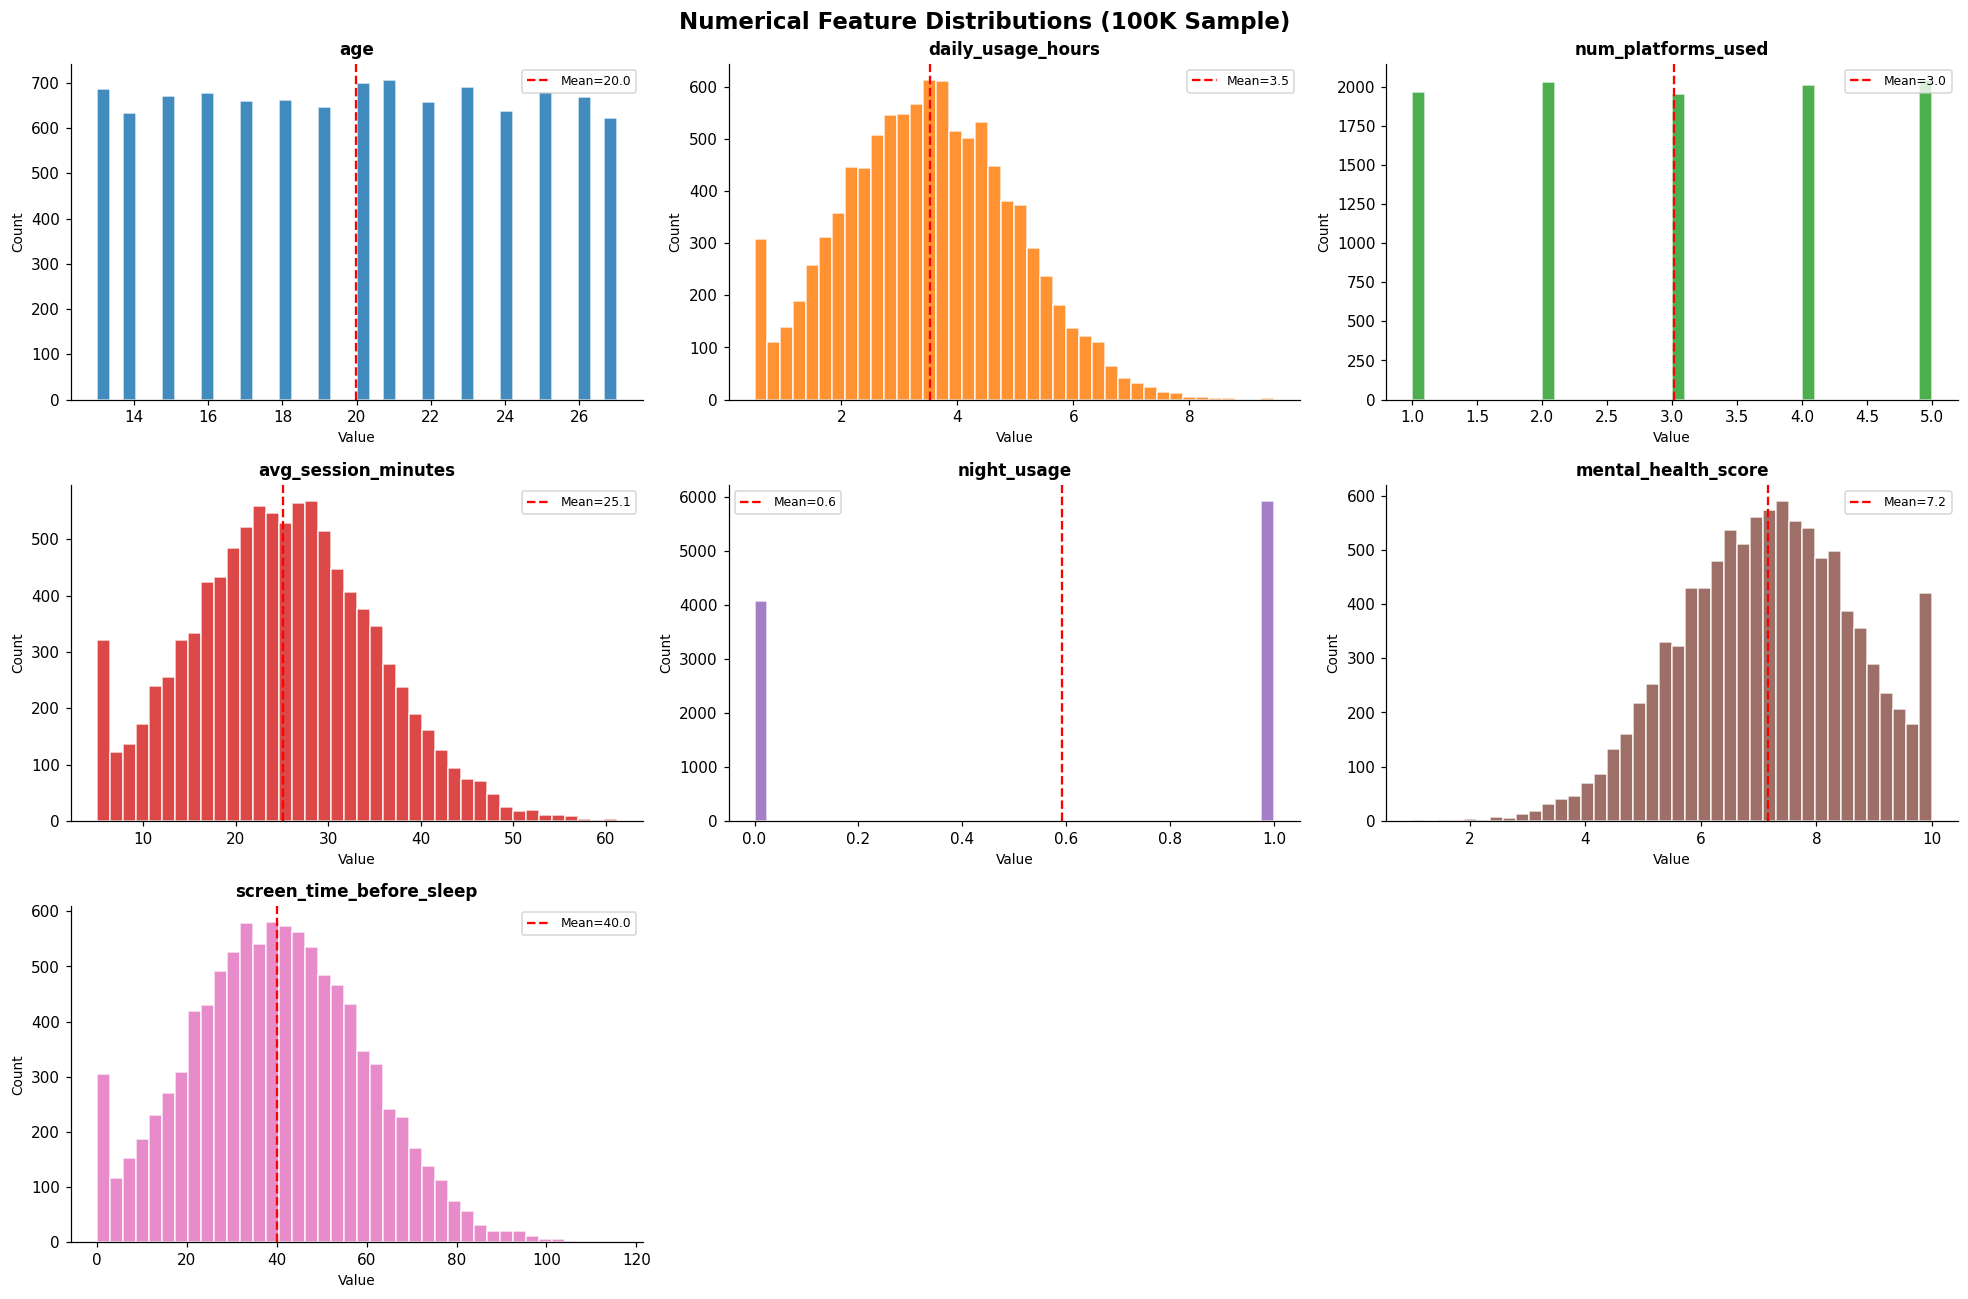

In [6]:
# ── Distribution plots for all numeric features ──────────────────────────────
num_cols_eda = data.select_dtypes(include=np.number).columns.tolist()
n_cols_plot  = 3
n_rows_plot  = (len(num_cols_eda) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, n_rows_plot * 4))
axes = axes.flatten()
colors = plt.cm.tab10.colors

for idx, col in enumerate(num_cols_eda):
    axes[idx].hist(data[col].dropna(), bins=40, color=colors[idx % 10], edgecolor='white', alpha=0.85)
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)
    mean_val = data[col].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
    axes[idx].legend(fontsize=8)

for idx in range(len(num_cols_eda), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Numerical Feature Distributions (100K Sample)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

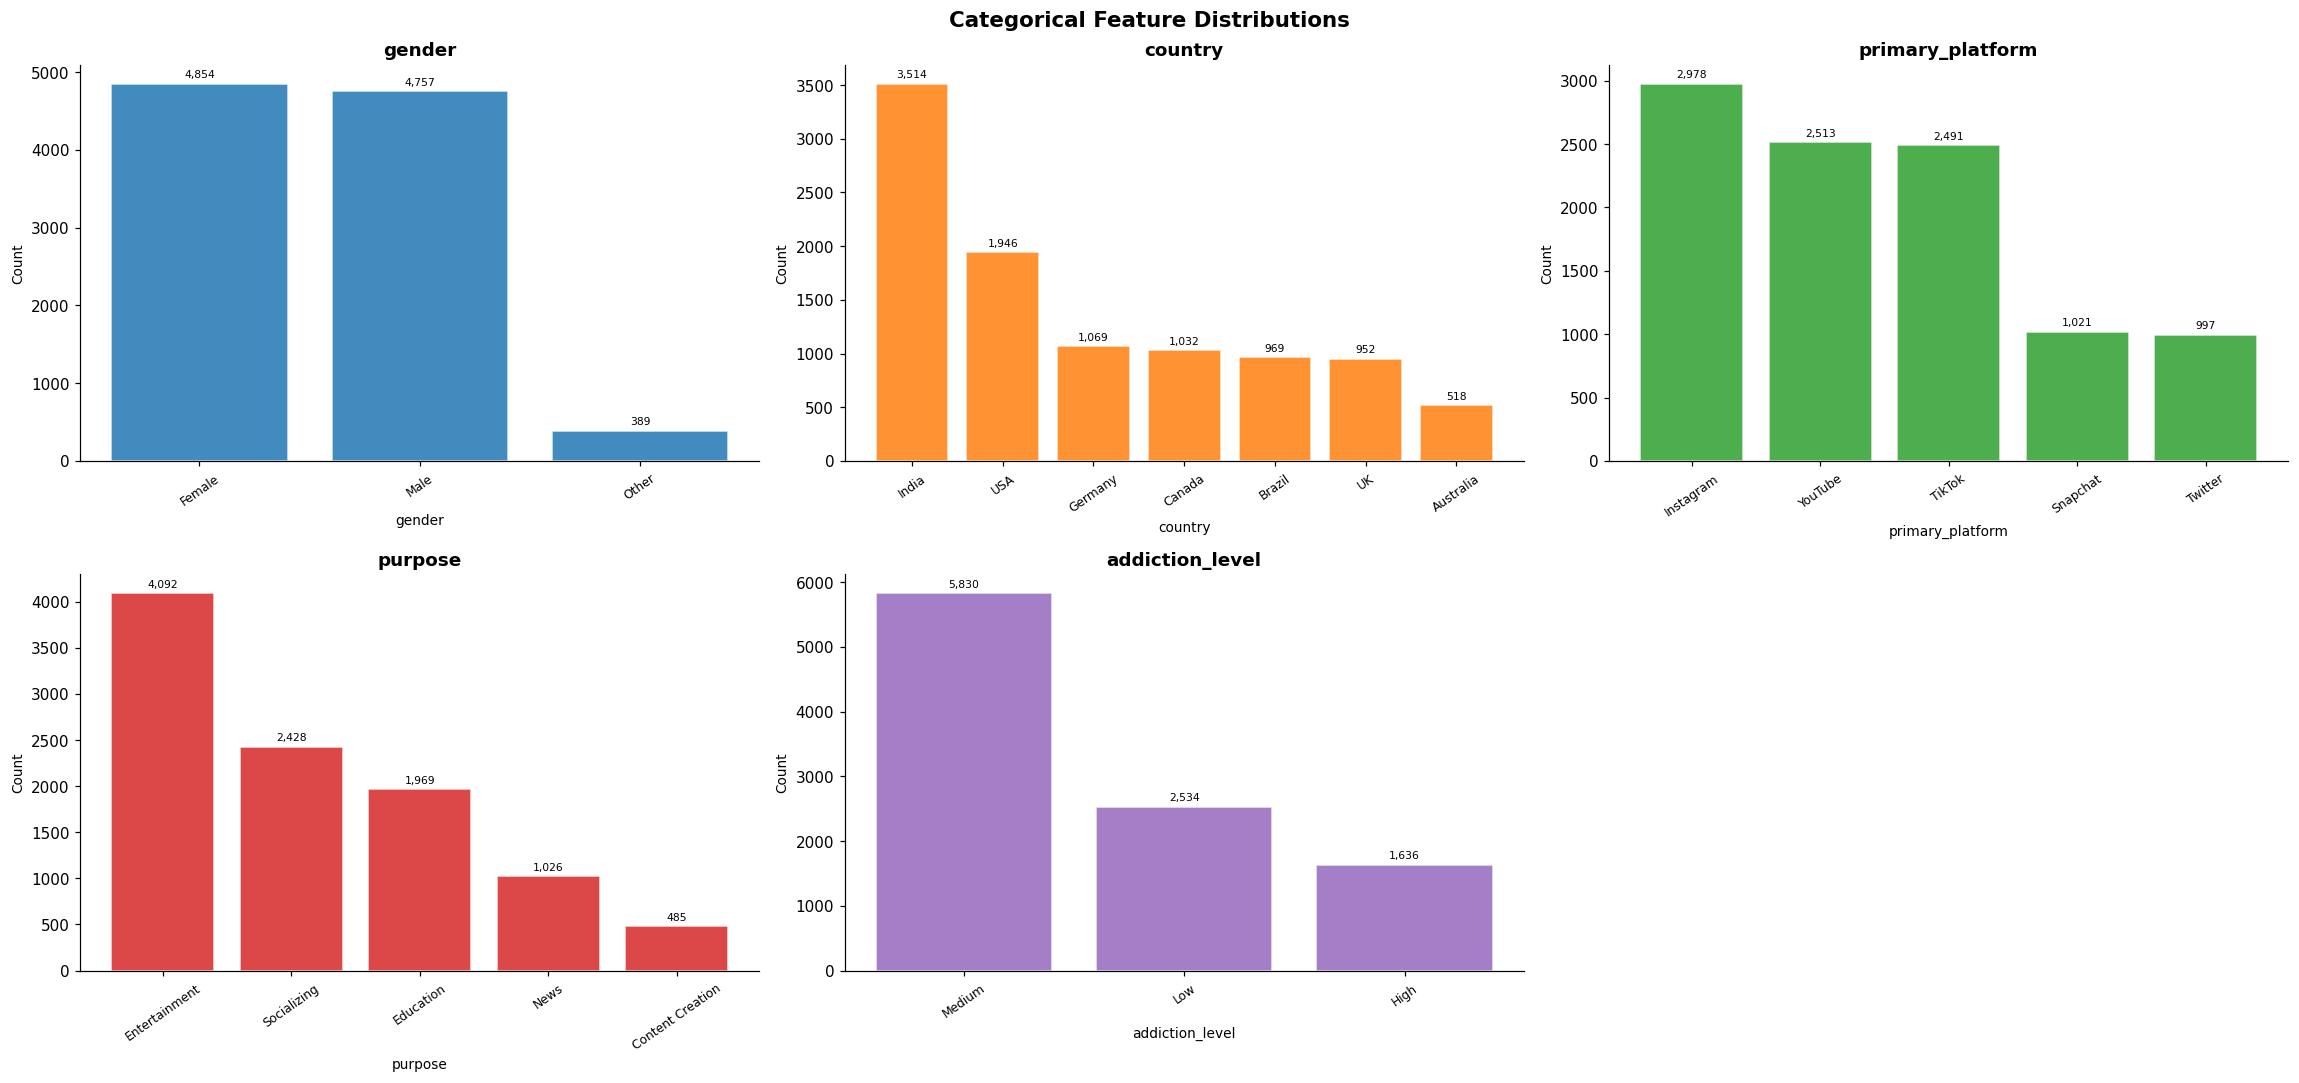

In [7]:
# ── Categorical feature value counts ─────────────────────────────────────────
cat_cols_eda = data.select_dtypes(include='object').columns.tolist()
n_cat = len(cat_cols_eda)

if n_cat > 0:
    n_cat_cols = min(3, n_cat)
    n_cat_rows = (n_cat + n_cat_cols - 1) // n_cat_cols
    fig, axes = plt.subplots(n_cat_rows, n_cat_cols, figsize=(7 * n_cat_cols, 5 * n_cat_rows))
    axes = np.array(axes).flatten()
    for i, (ax, col) in enumerate(zip(axes, cat_cols_eda)):
        vc = data[col].value_counts().head(15)
        bars = ax.bar(vc.index.astype(str), vc.values, color=colors[i % 10], edgecolor='white', alpha=0.85)
        ax.set_title(f'{col}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col, fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.tick_params(axis='x', rotation=35, labelsize=8)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(vc.values) * 0.01,
                    f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7)
    for ax in axes[n_cat:]:
        ax.set_visible(False)
    plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

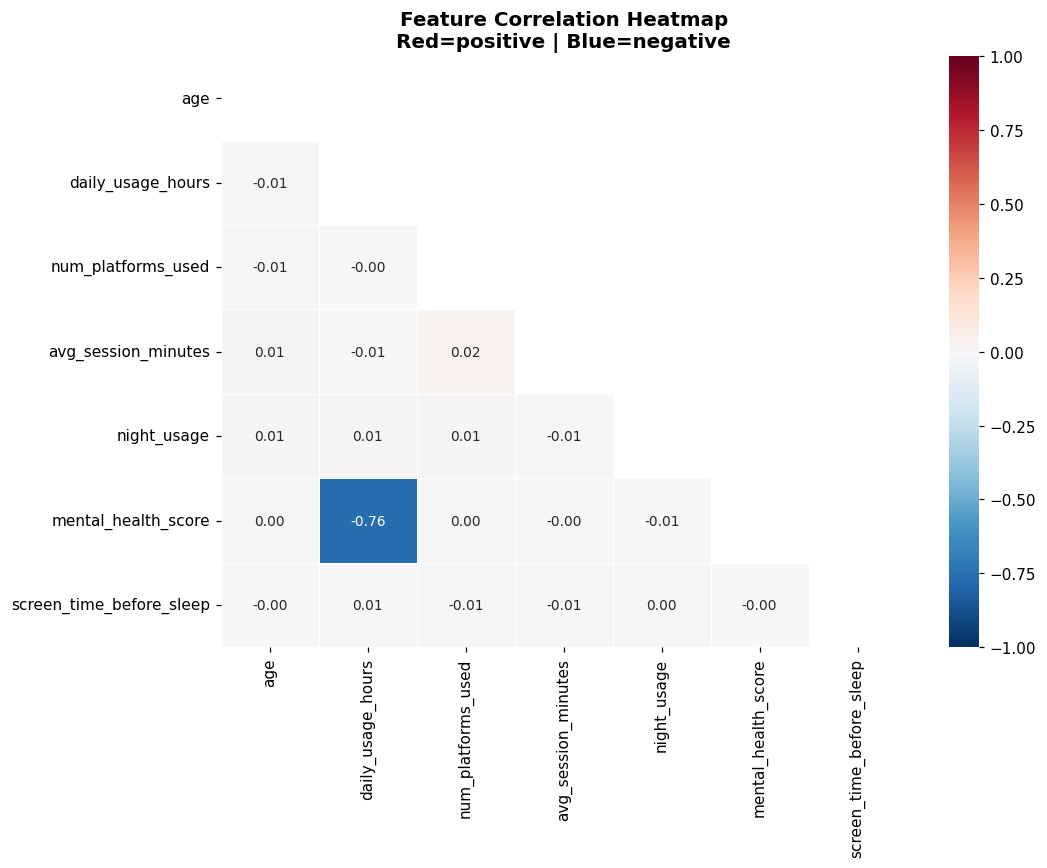


=== Highly Correlated Pairs (|r| > 0.5) ===
  mental_health_score                  <->  daily_usage_hours                    r = -0.763


In [8]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
num_cols_corr = data.select_dtypes(include=np.number).columns.tolist()
corr_matrix   = data[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(max(10, len(num_cols_corr)), max(8, len(num_cols_corr) - 1)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap\nRed=positive | Blue=negative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Highly Correlated Pairs (|r| > 0.5) ===')
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))
if high_corr:
    for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a:35s}  <->  {b:35s}  r = {r:+.3f}')
else:
    print('  No pairs with |r| > 0.5 found.')

## 2.4 Feature Engineering & Column Selection

| Column | Action | Reason |
|---|---|---|
| `mental_health_score` | **DROP** | Supervised target — leakage |
| `user_id` / `id` | **DROP** | Identifier |
| `session_intensity` | **ADD** | Derived: `daily_usage_hours * 60 / (avg_session_minutes + 1)` |
| Behavioural columns | **KEEP** | Core clustering signals |

In [9]:
df = data.copy()

# ── Derived feature: session intensity ───────────────────────────────────────
if 'daily_usage_hours' in df.columns and 'avg_session_minutes' in df.columns:
    df['session_intensity'] = (
        df['daily_usage_hours'] * 60 / (df['avg_session_minutes'] + 1)
    ).round(3)
    print('Derived feature added: session_intensity')
    print(f'  Mean: {df["session_intensity"].mean():.3f}  Std: {df["session_intensity"].std():.3f}')

print(f'\nShape after feature engineering: {df.shape}')

Derived feature added: session_intensity
  Mean: 9.972  Std: 7.701

Shape after feature engineering: (10000, 13)


## 2.5 Data Cleaning

| Step | Method | Justification |
|---|---|---|
| Drop target + ID | Explicit drop | Prevent label leakage |
| Missing value imputation | Median (numeric) / Mode (categorical) | Robust to outliers |
| Duplicate removal | `drop_duplicates()` | Bias prevention |
| Outlier clipping | 1st–99th percentile IQR | Clip without losing rows |

In [10]:
# ── Step 1: Drop supervised target + identifier columns ─────────────────────
cols_to_drop = ['mental_health_score']
id_like = [c for c in df.columns if c.lower() in ('user_id', 'id', 'index', 'respondent_id')]
cols_to_drop += id_like
dropped_actual = [c for c in cols_to_drop if c in df.columns]
df.drop(columns=dropped_actual, inplace=True)
print(f'Dropped columns: {dropped_actual}')
print(f'Shape after drop: {df.shape}')

# ── Step 2: Missing value imputation ────────────────────────────────────────
print('\n=== Missing Value Imputation ===')
imputed_cols = []
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().sum() > 0:
        fill_val = df[col].median()
        df[col].fillna(fill_val, inplace=True)
        imputed_cols.append(f'{col} (median={fill_val:.3f})')
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        fill_val = df[col].mode()[0]
        df[col].fillna(fill_val, inplace=True)
        imputed_cols.append(f'{col} (mode={fill_val})')
print(f'Imputed: {imputed_cols}' if imputed_cols else 'No imputation needed')

# ── Step 3: Remove duplicates ────────────────────────────────────────────────
dup_count = df.duplicated().sum()
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'\n{dup_count:,} duplicate rows removed.')
else:
    print('\nNo duplicates found')
print(f'\nShape after cleaning: {df.shape}')

Dropped columns: ['mental_health_score']
Shape after drop: (10000, 12)

=== Missing Value Imputation ===
No imputation needed

No duplicates found

Shape after cleaning: (10000, 12)


In [11]:
# ── Outlier Clipping (1st-99th percentile) ───────────────────────────────────
print('=== Outlier Clipping (1st-99th percentile) ===')
num_cols_clip = df.select_dtypes(include=np.number).columns.tolist()
clip_report = []

for col in num_cols_clip:
    q01 = df[col].quantile(0.01)
    q99 = df[col].quantile(0.99)
    n_clipped = ((df[col] < q01) | (df[col] > q99)).sum()
    df[col] = df[col].clip(lower=q01, upper=q99)
    if n_clipped > 0:
        clip_report.append(f'  {col:<35} clipped {n_clipped:,} values  [{q01:.2f}, {q99:.2f}]')

print('\n'.join(clip_report) if clip_report else 'No values outside 1st-99th percentile')
print(f'\nRows unchanged: {len(df):,}')
print('Outlier clipping complete')

=== Outlier Clipping (1st-99th percentile) ===
  daily_usage_hours                   clipped 100 values  [0.50, 6.99]
  avg_session_minutes                 clipped 100 values  [5.00, 48.48]
  screen_time_before_sleep            clipped 100 values  [0.00, 85.62]
  session_intensity                   clipped 200 values  [1.05, 42.95]

Rows unchanged: 10,000
Outlier clipping complete


## 2.6 Encoding Categorical Features

| Column | Encoding | Reason |
|---|---|---|
| `addiction_level` | **Ordinal** (Low=0, Medium=1, High=2) | Natural order exists |
| All other categoricals | **One-Hot** (`drop_first=True`) | No natural order |

In [12]:
df_enc = df.copy()

# ── Ordinal Encoding: addiction_level ───────────────────────────────────────
if 'addiction_level' in df_enc.columns:
    unique_vals = df_enc['addiction_level'].unique()
    print(f'addiction_level unique values: {sorted(unique_vals)}')
    ord_map = {'Low': 0, 'Medium': 1, 'High': 2}
    if all(v in ord_map for v in unique_vals):
        df_enc['addiction_level_ord'] = df_enc['addiction_level'].map(ord_map).astype(int)
    else:
        ord_enc = OrdinalEncoder()
        df_enc['addiction_level_ord'] = ord_enc.fit_transform(df_enc[['addiction_level']]).astype(int)
    df_enc.drop(columns=['addiction_level'], inplace=True)
    print('addiction_level -> addiction_level_ord  (Low=0, Medium=1, High=2)')
    print(df_enc['addiction_level_ord'].value_counts().sort_index().to_string())

# ── One-Hot Encoding: remaining categoricals ──────────────────────────────────
cat_remaining = df_enc.select_dtypes(include='object').columns.tolist()
print(f'\nOne-Hot encoding columns: {cat_remaining}')
df_enc = pd.get_dummies(df_enc, columns=cat_remaining, drop_first=True)

bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print(f'\nEncoding complete')
print(f'  Shape: {df_enc.shape}')
print(f'  Columns: {list(df_enc.columns)}')

addiction_level unique values: ['High', 'Low', 'Medium']
addiction_level -> addiction_level_ord  (Low=0, Medium=1, High=2)
addiction_level_ord
0    2534
1    5830
2    1636

One-Hot encoding columns: ['gender', 'country', 'primary_platform', 'purpose']

Encoding complete
  Shape: (10000, 24)
  Columns: ['age', 'daily_usage_hours', 'num_platforms_used', 'avg_session_minutes', 'night_usage', 'screen_time_before_sleep', 'session_intensity', 'addiction_level_ord', 'gender_Male', 'gender_Other', 'country_Brazil', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'primary_platform_Snapchat', 'primary_platform_TikTok', 'primary_platform_Twitter', 'primary_platform_YouTube', 'purpose_Education', 'purpose_Entertainment', 'purpose_News', 'purpose_Socializing']


## 2.7 Remove Near-Zero Variance Features

`VarianceThreshold(threshold=0.001)` removes columns that are constant or near-constant — they add noise without contributing to cluster separation.

In [13]:
VARIANCE_THRESHOLD = 0.001
selector = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
X_selected = pd.DataFrame(
    selector.fit_transform(df_enc),
    columns=df_enc.columns[selector.get_support()]
)

removed_nzv  = df_enc.shape[1] - X_selected.shape[1]
removed_cols = df_enc.columns[~selector.get_support()].tolist()

print(f'Variance threshold : {VARIANCE_THRESHOLD}')
print(f'Features before    : {df_enc.shape[1]}')
print(f'Features removed   : {removed_nzv}')
if removed_cols:
    print(f'  Removed: {removed_cols}')
print(f'Features remaining : {X_selected.shape[1]}')
print(f'\nFinal features:')
for i, col in enumerate(X_selected.columns):
    print(f'  [{i:02d}] {col:<40} var={X_selected[col].var():.4f}')

Variance threshold : 0.001
Features before    : 24
Features removed   : 0
Features remaining : 24

Final features:
  [00] age                                      var=18.4646
  [01] daily_usage_hours                        var=2.1166
  [02] num_platforms_used                       var=2.0069
  [03] avg_session_minutes                      var=95.3592
  [04] night_usage                              var=0.2415
  [05] screen_time_before_sleep                 var=366.7987
  [06] session_intensity                        var=52.5822
  [07] addiction_level_ord                      var=0.4090
  [08] gender_Male                              var=0.2494
  [09] gender_Other                             var=0.0374
  [10] country_Brazil                           var=0.0875
  [11] country_Canada                           var=0.0926
  [12] country_Germany                          var=0.0955
  [13] country_India                            var=0.2279
  [14] country_UK                               var=0.

## 2.8 Normalization — StandardScaler

K-Means and DBSCAN use **Euclidean distance**. Without normalization, features with large ranges dominate:

Normalization (StandardScaler) complete
  Shape       : (10000, 24)
  Global mean : 0.00000000  (should be ~0)
  Global std  : 1.00000000   (should be ~1)


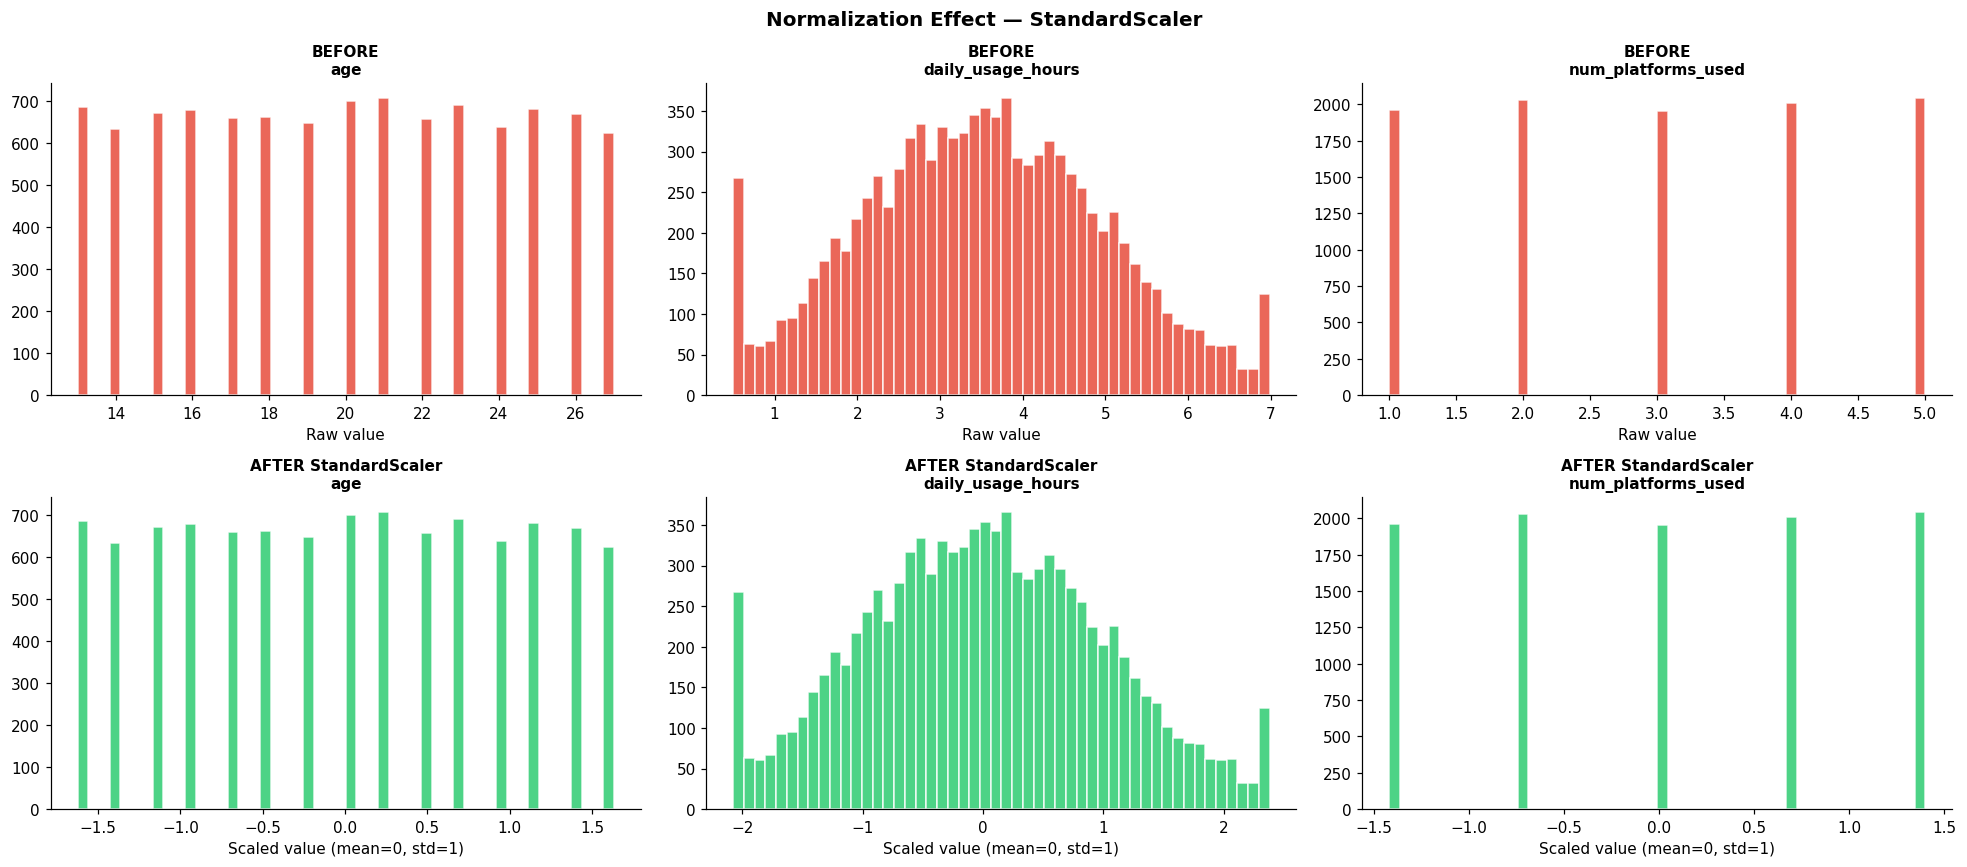


=== Summary After Scaling ===
                           mean     std     min     max
age                         0.0  1.0001 -1.6246  1.6336
daily_usage_hours          -0.0  1.0001 -2.0755  2.3826
num_platforms_used         -0.0  1.0001 -1.4217  1.4020
avg_session_minutes         0.0  1.0001 -2.0542  2.3982
night_usage                -0.0  1.0001 -1.2056  0.8295
screen_time_before_sleep    0.0  1.0001 -2.0832  2.3875
session_intensity          -0.0  1.0001 -1.2187  4.5587
addiction_level_ord        -0.0  1.0001 -1.4233  1.7042
gender_Male                -0.0  1.0001 -0.9525  1.0498
gender_Other               -0.0  1.0001 -0.2012  4.9706
country_Brazil             -0.0  1.0001 -0.3276  3.0529
country_Canada              0.0  1.0001 -0.3392  2.9479
country_Germany            -0.0  1.0001 -0.3460  2.8904
country_India               0.0  1.0001 -0.7361  1.3586
country_UK                 -0.0  1.0001 -0.3244  3.0829
country_USA                -0.0  1.0001 -0.4915  2.0344
primary_platform_

In [14]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_selected.columns)

print('Normalization (StandardScaler) complete')
print(f'  Shape       : {X_scaled_df.shape}')
print(f'  Global mean : {X_scaled_df.values.mean():.8f}  (should be ~0)')
print(f'  Global std  : {X_scaled_df.values.std():.8f}   (should be ~1)')

# ── Before / After comparison ──────────────────────────────────────────────
example_cols = X_selected.columns[:min(3, len(X_selected.columns))].tolist()
fig, axes = plt.subplots(2, len(example_cols), figsize=(6 * len(example_cols), 8))

for idx, col in enumerate(example_cols):
    axes[0, idx].hist(X_selected[col], bins=50, color='#e74c3c', edgecolor='white', alpha=0.85)
    axes[0, idx].set_title(f'BEFORE\n{col}', fontsize=10, fontweight='bold')
    axes[0, idx].set_xlabel('Raw value')
    axes[1, idx].hist(X_scaled_df[col], bins=50, color='#2ecc71', edgecolor='white', alpha=0.85)
    axes[1, idx].set_title(f'AFTER StandardScaler\n{col}', fontsize=10, fontweight='bold')
    axes[1, idx].set_xlabel('Scaled value (mean=0, std=1)')

plt.suptitle('Normalization Effect — StandardScaler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Summary After Scaling ===')
print(X_scaled_df.describe().round(4).T[['mean','std','min','max']].to_string())

---
# TASK 3 — Dimensionality Reduction

## 3.1 PCA — Principal Component Analysis

PCA finds **orthogonal directions** that capture maximum variance.

**Selection rule:** minimum components explaining **>=85%** of total variance.

**Why PCA before clustering?** The *curse of dimensionality*: as features grow, Euclidean distance between all points converges — making distance-based clustering meaningless. PCA compresses features into uncorrelated components.

Total original features  : 24
Components for 80% var   : 15
Components for 85% var   : 16  <- selected
Components for 95% var   : 19


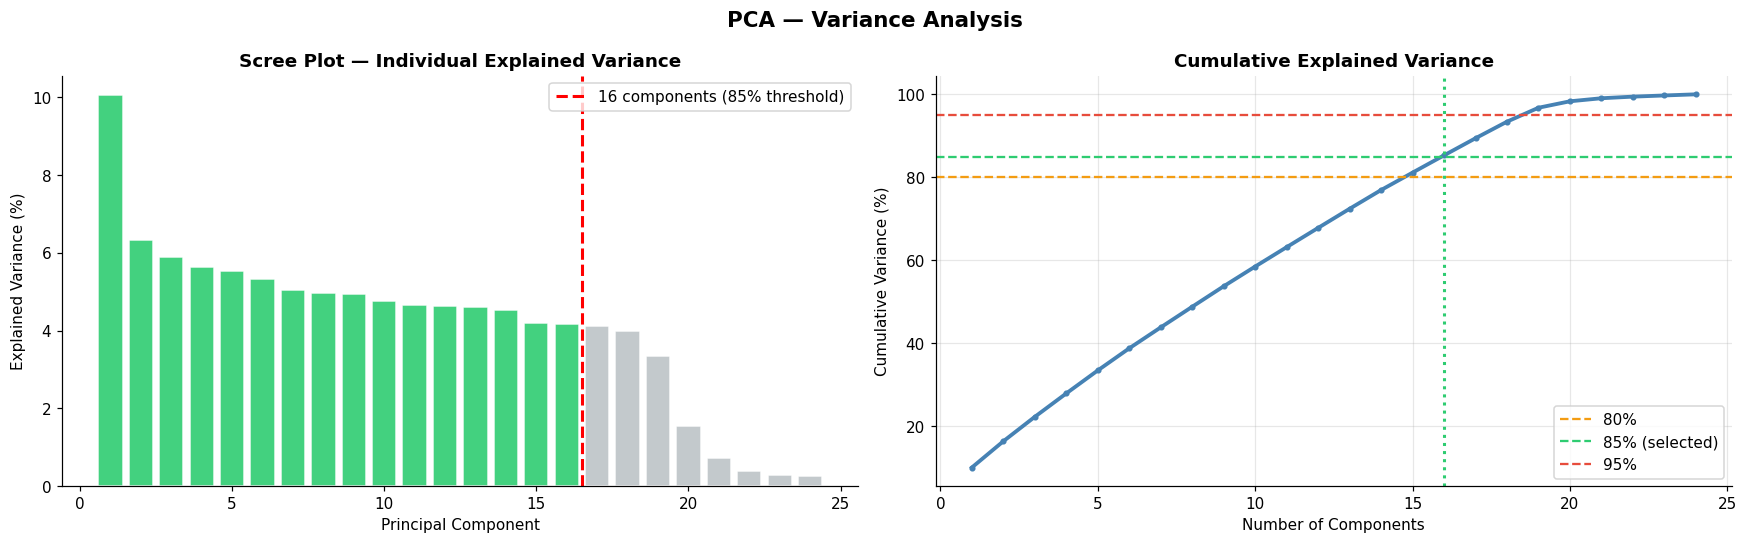


Top Component Variance:
  PC01:  10.05%  xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

In [15]:
# ── PCA: full variance analysis ──────────────────────────────────────────────
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained_var   = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_var)
n_components_80 = np.argmax(cumulative_var >= 0.80) + 1
n_components_85 = np.argmax(cumulative_var >= 0.85) + 1
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f'Total original features  : {X_scaled.shape[1]}')
print(f'Components for 80% var   : {n_components_80}')
print(f'Components for 85% var   : {n_components_85}  <- selected')
print(f'Components for 95% var   : {n_components_95}')

# ── Scree + Cumulative variance plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
show_n = min(30, len(explained_var))
bar_colors = ['#2ecc71' if i < n_components_85 else '#bdc3c7' for i in range(show_n)]

axes[0].bar(range(1, show_n + 1), explained_var[:show_n] * 100,
            color=bar_colors, edgecolor='white', alpha=0.9)
axes[0].axvline(n_components_85 + 0.5, color='red', linestyle='--',
                linewidth=2, label=f'{n_components_85} components (85% threshold)')
axes[0].set_title('Scree Plot — Individual Explained Variance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].legend()

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100,
             color='steelblue', linewidth=2.5, marker='o', markersize=3)
axes[1].axhline(80, color='#f39c12', linestyle='--', linewidth=1.5, label='80%')
axes[1].axhline(85, color='#2ecc71', linestyle='--', linewidth=1.5, label='85% (selected)')
axes[1].axhline(95, color='#e74c3c', linestyle='--', linewidth=1.5, label='95%')
axes[1].axvline(n_components_85, color='#2ecc71', linestyle=':', linewidth=2)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA — Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nTop Component Variance:')
for i, ev in enumerate(explained_var[:min(10, len(explained_var))], 1):
    bar = 'x' * int(ev * 100 / explained_var[0] * 30)
    print(f'  PC{i:02d}: {ev*100:6.2f}%  {bar}')
print(f'\nSelected N_PCA = {n_components_85} components (>= 85% variance = {cumulative_var[n_components_85-1]*100:.2f}%)')

PCA applied:
  Input  shape     : (10000, 24)
  Output shape     : (10000, 16)
  Variance retained: 85.29%


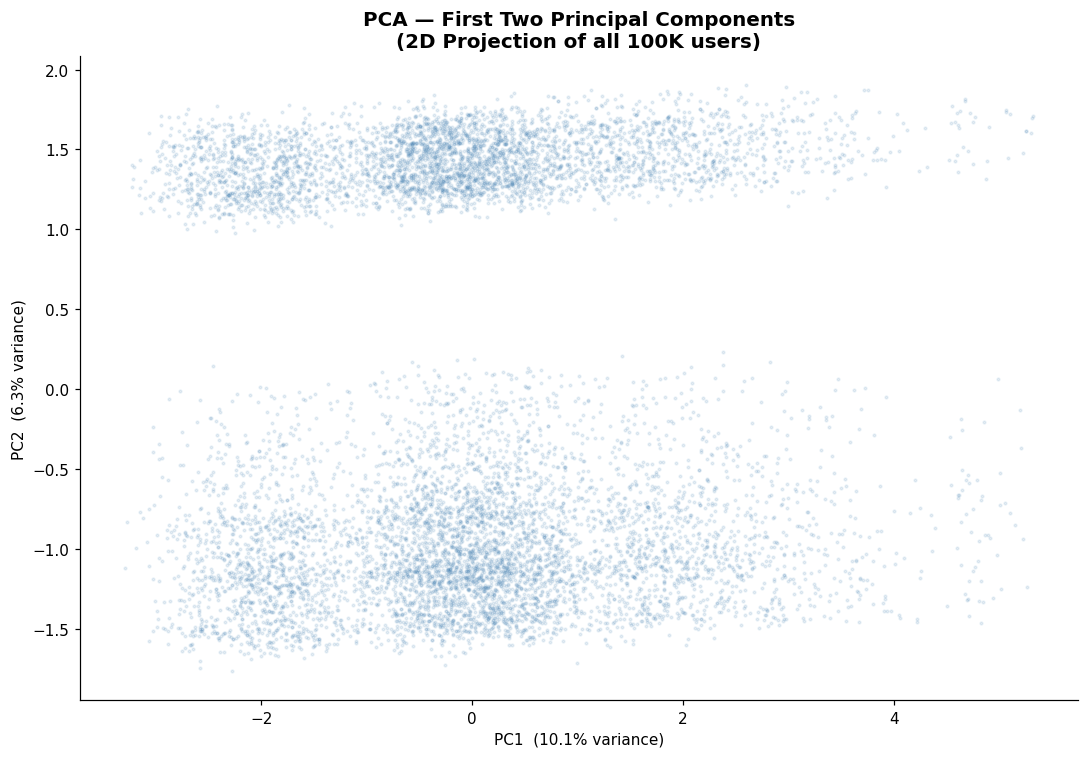


=== Top 10 Feature Loadings on PC1 ===
  + daily_usage_hours                        +0.5674
  + addiction_level_ord                      +0.5560
  + session_intensity                        +0.5447
  - avg_session_minutes                      -0.2633
  + purpose_Socializing                      +0.0303
  - purpose_Entertainment                    -0.0252
  - country_Brazil                           -0.0142
  - age                                      -0.0141
  + night_usage                              +0.0122
  - num_platforms_used                       -0.0121

=== Top 10 Feature Loadings on PC2 ===
  + purpose_Entertainment                    +0.7848
  - purpose_Socializing                      -0.4892
  - purpose_Education                        -0.3195
  - purpose_News                             -0.1434
  + screen_time_before_sleep                 +0.0732
  - country_India                            -0.0712
  + country_USA                              +0.0684
  + country_Brazil 

In [16]:
# ── Apply PCA with optimal number of components ──────────────────────────────
N_PCA = n_components_85
pca   = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA applied:')
print(f'  Input  shape     : {X_scaled.shape}')
print(f'  Output shape     : {X_pca.shape}')
print(f'  Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

# ── 2D PCA scatter ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.12, s=3, color='steelblue', rasterized=True)
ax.set_title('PCA — First Two Principal Components\n(2D Projection of all 100K users)',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

# ── Feature Loadings ──────────────────────────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=X_selected.columns,
    columns=['PC1', 'PC2']
).round(4)

print('\n=== Top 10 Feature Loadings on PC1 ===')
top_pc1 = loadings['PC1'].abs().nlargest(10)
for feat in top_pc1.index:
    val = loadings.loc[feat, 'PC1']
    print(f'  {"+" if val > 0 else "-"} {feat:<40} {val:+.4f}')

print('\n=== Top 10 Feature Loadings on PC2 ===')
top_pc2 = loadings['PC2'].abs().nlargest(10)
for feat in top_pc2.index:
    val = loadings.loc[feat, 'PC2']
    print(f'  {"+" if val > 0 else "-"} {feat:<40} {val:+.4f}')

## 3.2 t-SNE — Non-linear 2D Visualization

| Aspect | PCA | t-SNE |
|---|---|---|
| **Type** | Linear | Non-linear |
| **Goal** | Retain global variance | Preserve local neighbourhood |
| **Interpretable axes?** | Yes | No |
| **Use in clustering?** | Yes | No — visualization only |

> t-SNE runs on a 5,000-row subsample for speed. All clustering uses the full 100K PCA output.

t-SNE input shape : (5000, 16)
Running t-SNE... (may take 1-3 minutes)


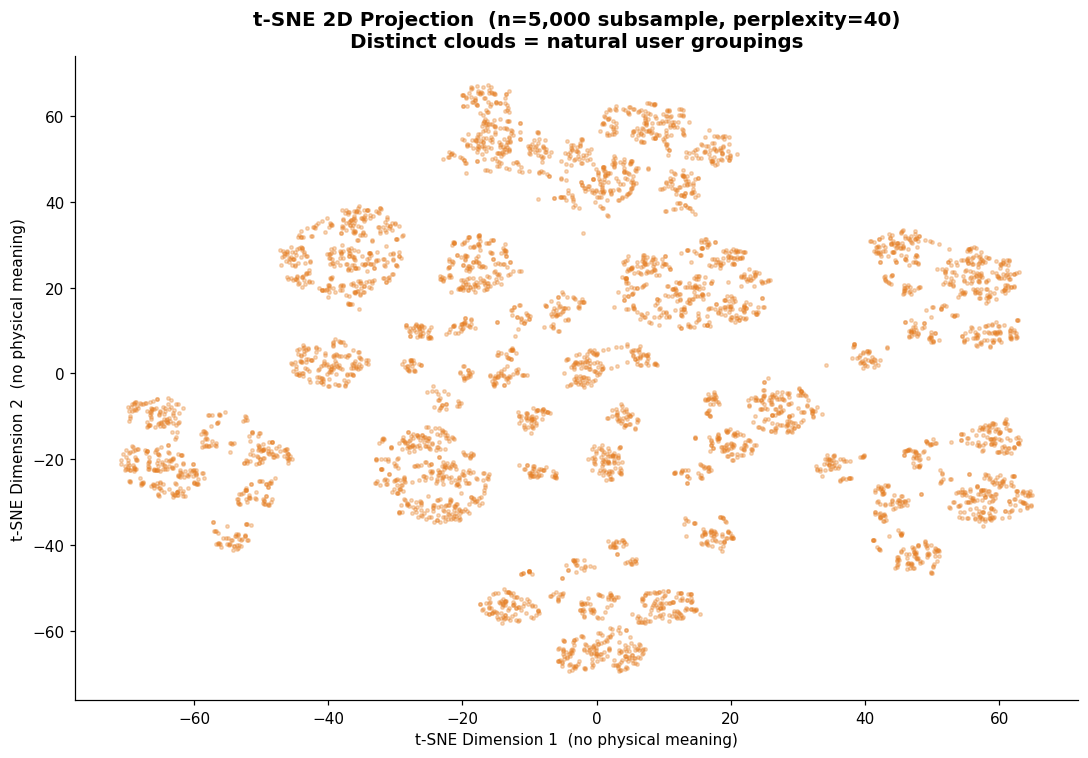

t-SNE complete
  Distinct clouds of points = well-separated user groups


In [17]:
# ── t-SNE on 5,000-row PCA subsample ────────────────────────────────────────
TSNE_SAMPLE = 5_000
tsne_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(X_pca), size=min(TSNE_SAMPLE, len(X_pca)), replace=False
)
X_tsne_input = X_pca[tsne_idx]

print(f't-SNE input shape : {X_tsne_input.shape}')
print('Running t-SNE... (may take 1-3 minutes)')

tsne = TSNE(
    n_components=2, perplexity=40, n_iter=1000,
    random_state=RANDOM_STATE, learning_rate='auto', init='pca'
)
X_tsne = tsne.fit_transform(X_tsne_input)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.3, s=5, color='#e67e22', rasterized=True)
ax.set_title(f't-SNE 2D Projection  (n={TSNE_SAMPLE:,} subsample, perplexity=40)\n'
             'Distinct clouds = natural user groupings', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1  (no physical meaning)')
ax.set_ylabel('t-SNE Dimension 2  (no physical meaning)')
plt.tight_layout()
plt.show()

print('t-SNE complete')
print('  Distinct clouds of points = well-separated user groups')

---
# TASK 4 — Clustering Models

## 4.1 K-Means Clustering

| Step | Description |
|---|---|
| 1. Initialise | K-Means++ — smart centroid initialization |
| 2. Assign | Each point → nearest centroid (Euclidean) |
| 3. Update | Recompute centroids as cluster means |
| 4. Repeat | Until convergence |

**Optimal K selection:**
- **Elbow Method** — inertia vs K, look for the bend
- **Silhouette Score** — peak score = optimal K

Evaluating K-Means for K = 2 to 10...
------------------------------------------------------------
  K= 2: Inertia=        189,888   Silhouette=0.0738
  K= 3: Inertia=        178,063   Silhouette=0.1033
  K= 4: Inertia=        169,538   Silhouette=0.1137
  K= 5: Inertia=        160,544   Silhouette=0.1190
  K= 6: Inertia=        151,493   Silhouette=0.1230
  K= 7: Inertia=        140,884   Silhouette=0.1478
  K= 8: Inertia=        136,363   Silhouette=0.1391
  K= 9: Inertia=        134,792   Silhouette=0.1322
  K=10: Inertia=        126,605   Silhouette=0.1292


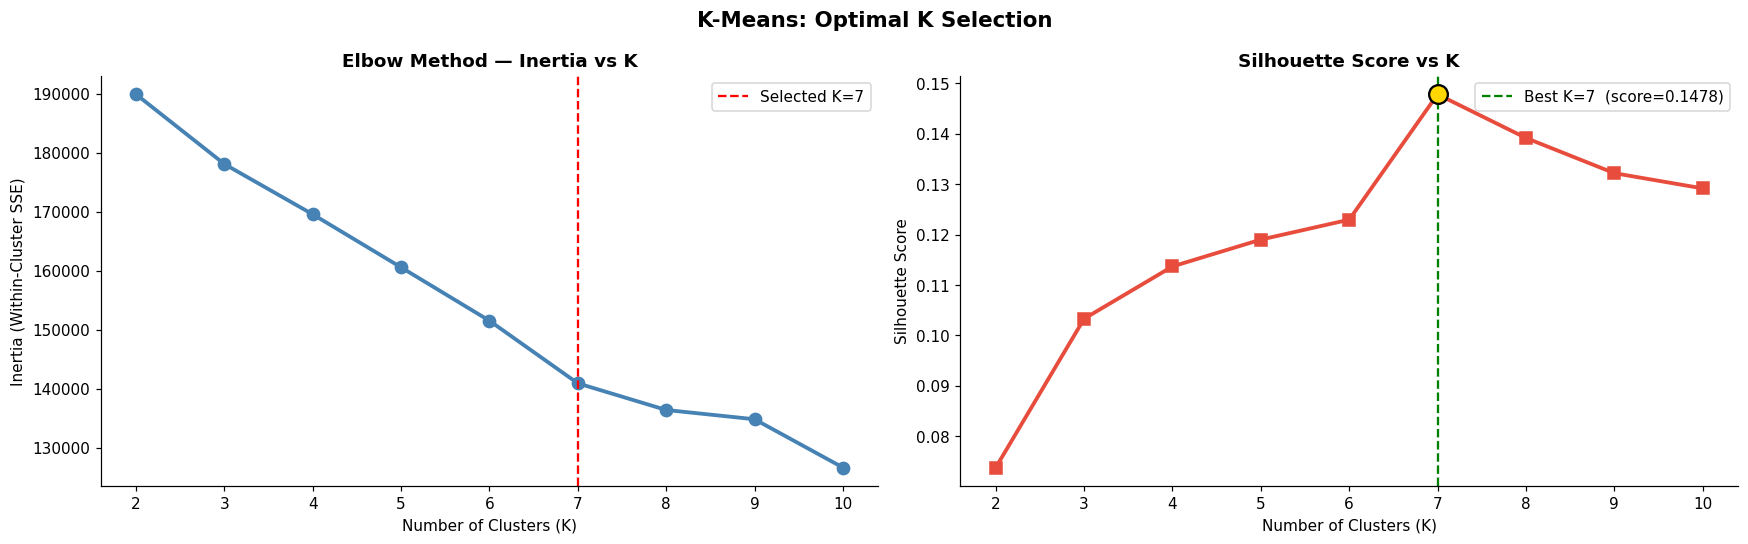


Best K by Silhouette Score: K = 7
Silhouette scores:
  K=2: 0.0738
  K=3: 0.1033
  K=4: 0.1137
  K=5: 0.1190
  K=6: 0.1230
  K=7: 0.1478 <- BEST
  K=8: 0.1391
  K=9: 0.1322
  K=10: 0.1292


In [18]:
# ── K-Means: Elbow + Silhouette ──────────────────────────────────────────────
K_RANGE    = range(2, 11)
inertias   = []
sil_scores = []

print('Evaluating K-Means for K = 2 to 10...')
print('-' * 60)
for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca, labels, sample_size=10_000, random_state=RANDOM_STATE)
    sil_scores.append(sil)
    print(f'  K={k:>2}: Inertia={km.inertia_:>15,.0f}   Silhouette={sil:.4f}')

best_k = list(K_RANGE)[np.argmax(sil_scores)]
k_list = list(K_RANGE)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(k_list, inertias, marker='o', color='steelblue', linewidth=2.5, markersize=8)
axes[0].axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Selected K={best_k}')
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_xticks(k_list)
axes[0].legend()

axes[1].plot(k_list, sil_scores, marker='s', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].axvline(best_k, color='green', linestyle='--', linewidth=1.5,
                label=f'Best K={best_k}  (score={max(sil_scores):.4f})')
axes[1].scatter([best_k], [max(sil_scores)], s=150, color='gold', zorder=5, edgecolors='black', linewidth=1.5)
axes[1].set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(k_list)
axes[1].legend()

plt.suptitle('K-Means: Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nBest K by Silhouette Score: K = {best_k}')
print(f'Silhouette scores:')
for k, s in zip(k_list, sil_scores):
    marker = ' <- BEST' if k == best_k else ''
    print(f'  K={k}: {s:.4f}{marker}')

K-Means Final Model (K=7):
  Silhouette Score     : 0.1478  (range -1 to +1; higher = better)
  Davies-Bouldin Score : 2.0852  (>= 0; lower = better)
  Calinski-Harabasz    : 754.44  (>= 0; higher = better)


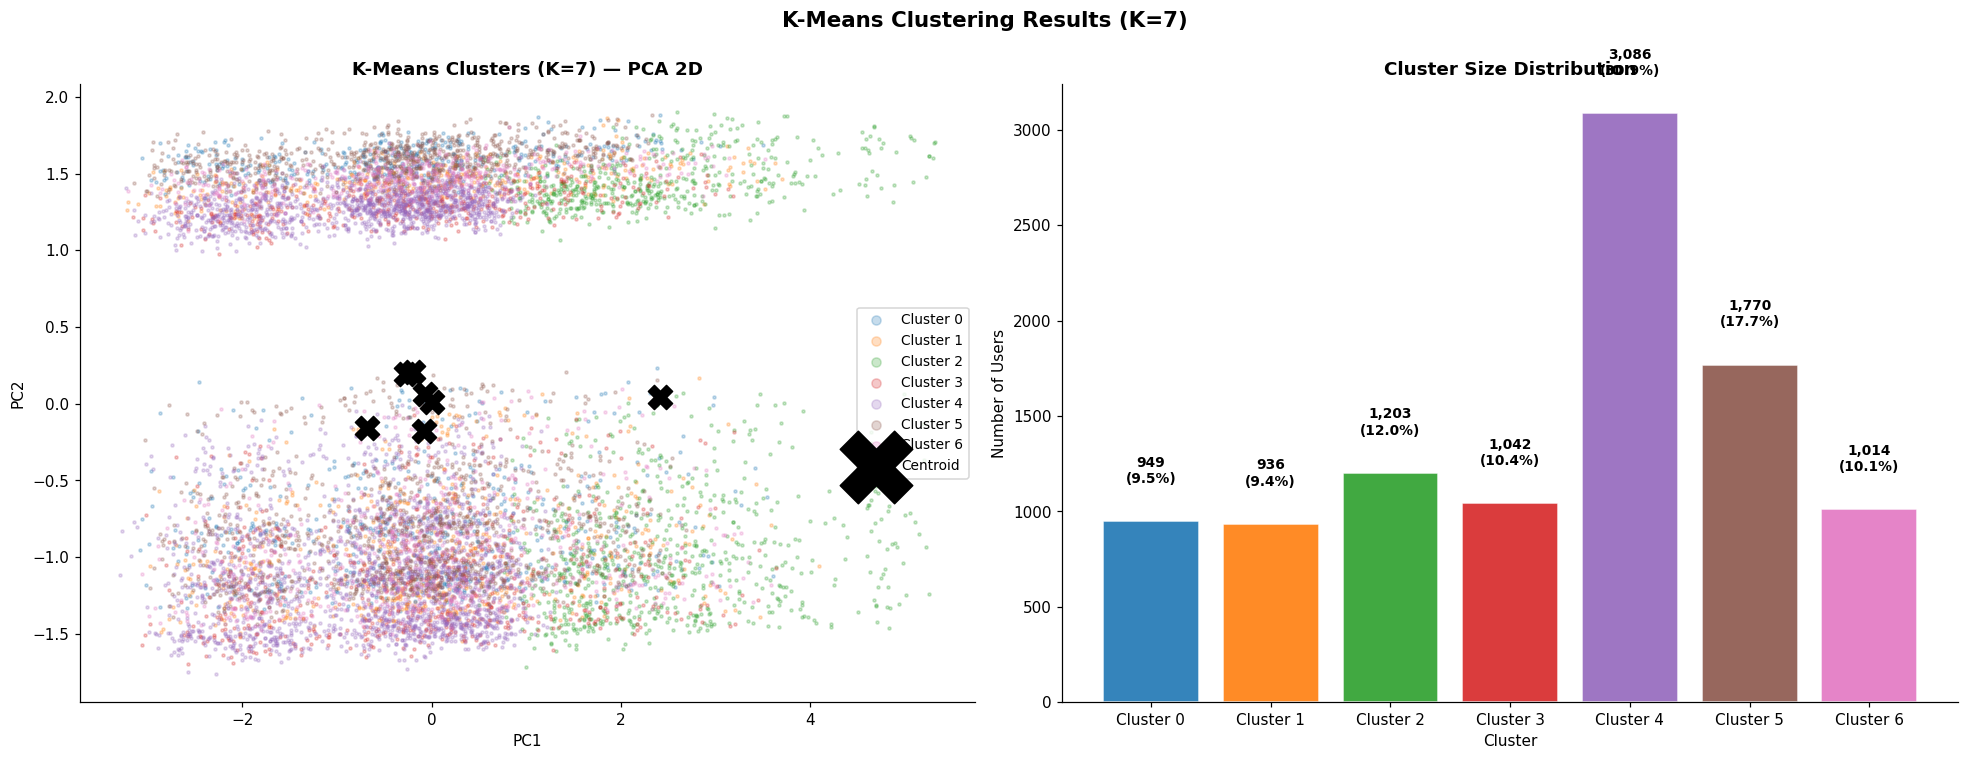


Cluster size distribution:
  Cluster 0:     949 (  9.5%)
  Cluster 1:     936 (  9.4%)
  Cluster 2:   1,203 ( 12.0%)
  Cluster 3:   1,042 ( 10.4%)
  Cluster 4:   3,086 ( 30.9%)
  Cluster 5:   1,770 ( 17.7%)
  Cluster 6:   1,014 ( 10.1%)


In [19]:
palette = plt.cm.tab10.colors

km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=20,
                  max_iter=500, random_state=RANDOM_STATE)
km_labels = km_final.fit_predict(X_pca)

sil_final = silhouette_score(X_pca, km_labels)
db_final  = davies_bouldin_score(X_pca, km_labels)
ch_final  = calinski_harabasz_score(X_pca, km_labels)

print(f'K-Means Final Model (K={best_k}):')
print(f'  Silhouette Score     : {sil_final:.4f}  (range -1 to +1; higher = better)')
print(f'  Davies-Bouldin Score : {db_final:.4f}  (>= 0; lower = better)')
print(f'  Calinski-Harabasz    : {ch_final:.2f}  (>= 0; higher = better)')

# ── Cluster scatter + size bar ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for c in range(best_k):
    mask = km_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=4, alpha=0.25,
               color=palette[c % 10], label=f'Cluster {c}', rasterized=True)
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], s=250, c='black', marker='X', zorder=10, label='Centroid')
ax.set_title(f'K-Means Clusters (K={best_k}) — PCA 2D', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(fontsize=9, markerscale=3)

cluster_sizes = pd.Series(km_labels).value_counts().sort_index()
ax2 = axes[1]
bars = ax2.bar([f'Cluster {c}' for c in cluster_sizes.index],
               cluster_sizes.values,
               color=[palette[c % 10] for c in cluster_sizes.index],
               edgecolor='white', alpha=0.9)
for bar, cnt in zip(bars, cluster_sizes.values):
    pct = cnt / len(km_labels) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Cluster Size Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Number of Users')

plt.suptitle(f'K-Means Clustering Results (K={best_k})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nCluster size distribution:')
for c, cnt in cluster_sizes.items():
    pct = cnt / len(km_labels) * 100
    print(f'  Cluster {c}: {cnt:>7,} ({pct:5.1f}%)')


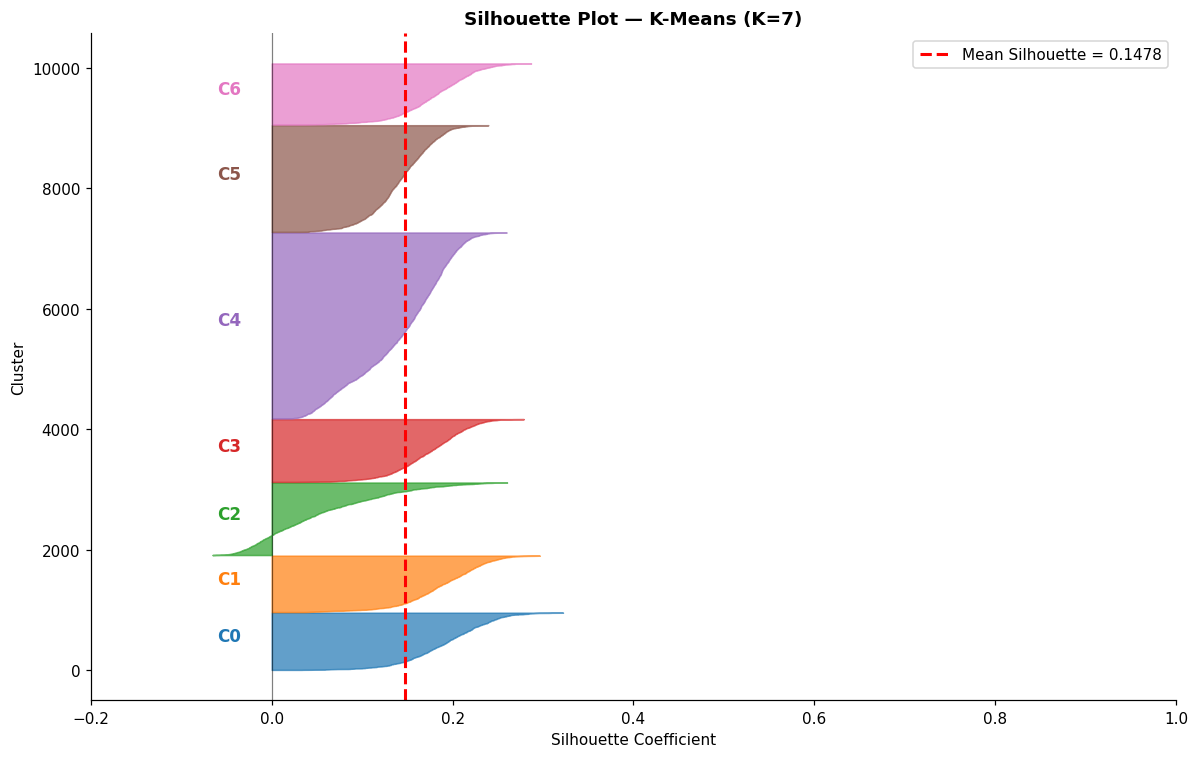


=== Per-Cluster Silhouette Statistics ===
  Cluster 0: mean=0.1933  std=0.0461  min=0.0332  max=0.3221  n=949
  Cluster 1: mean=0.1879  std=0.0447  min=0.0347  max=0.2963  n=936
  Cluster 2: mean=0.0531  std=0.0697  min=-0.0657  max=0.2602  n=1,203
  Cluster 3: mean=0.1740  std=0.0396  min=0.0288  max=0.2787  n=1,042
  Cluster 4: mean=0.1422  std=0.0522  min=0.0164  max=0.2597  n=3,086
  Cluster 5: mean=0.1422  std=0.0348  min=0.0311  max=0.2395  n=1,770
  Cluster 6: mean=0.1805  std=0.0415  min=0.0366  max=0.2868  n=1,014


In [20]:
# ── Silhouette Plot ───────────────────────────────────────────────────────────
sil_sample_size = min(10_000, len(X_pca))
sil_idx  = np.random.default_rng(RANDOM_STATE).choice(len(X_pca), sil_sample_size, replace=False)
X_sil    = X_pca[sil_idx]
lbl_sil  = km_labels[sil_idx]
sil_vals = silhouette_samples(X_sil, lbl_sil)

fig, ax = plt.subplots(figsize=(11, 7))
y_lower = 10
for c in range(best_k):
    c_sil  = np.sort(sil_vals[lbl_sil == c])
    y_upper = y_lower + c_sil.shape[0]
    color  = palette[c % 10]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.06, y_lower + 0.5 * c_sil.shape[0],
            f'C{c}', fontsize=11, fontweight='bold', color=color)
    y_lower = y_upper + 10

ax.axvline(sil_final, color='red', linestyle='--', linewidth=2,
           label=f'Mean Silhouette = {sil_final:.4f}')
ax.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_title(f'Silhouette Plot — K-Means (K={best_k})', fontsize=12, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_xlim([-0.2, 1.0])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('\n=== Per-Cluster Silhouette Statistics ===')
for c in range(best_k):
    c_sil = sil_vals[lbl_sil == c]
    print(f'  Cluster {c}: mean={c_sil.mean():.4f}  std={c_sil.std():.4f}  '
          f'min={c_sil.min():.4f}  max={c_sil.max():.4f}  n={len(c_sil):,}')

## 4.2 DBSCAN Clustering

DBSCAN classifies every point as:
- **Core point** — >= `min_samples` neighbours within `eps`
- **Border point** — within `eps` of a core point
- **Noise point (-1)** — genuine outlier

| Parameter | Selection Method |
|---|---|
| `eps` | k-distance graph — 90th percentile |
| `min_samples` | Rule: 2 x n_PCA_components |

| Feature | K-Means | DBSCAN |
|---|---|---|
| Specify K? | Required | Not needed |
| Cluster shape | Spherical | Any shape |
| Outliers | All assigned | Labelled as -1 |

min_samples (2 x PCA dims = 2 x 16): 32
Running 32-NN on 10,000 subsample...


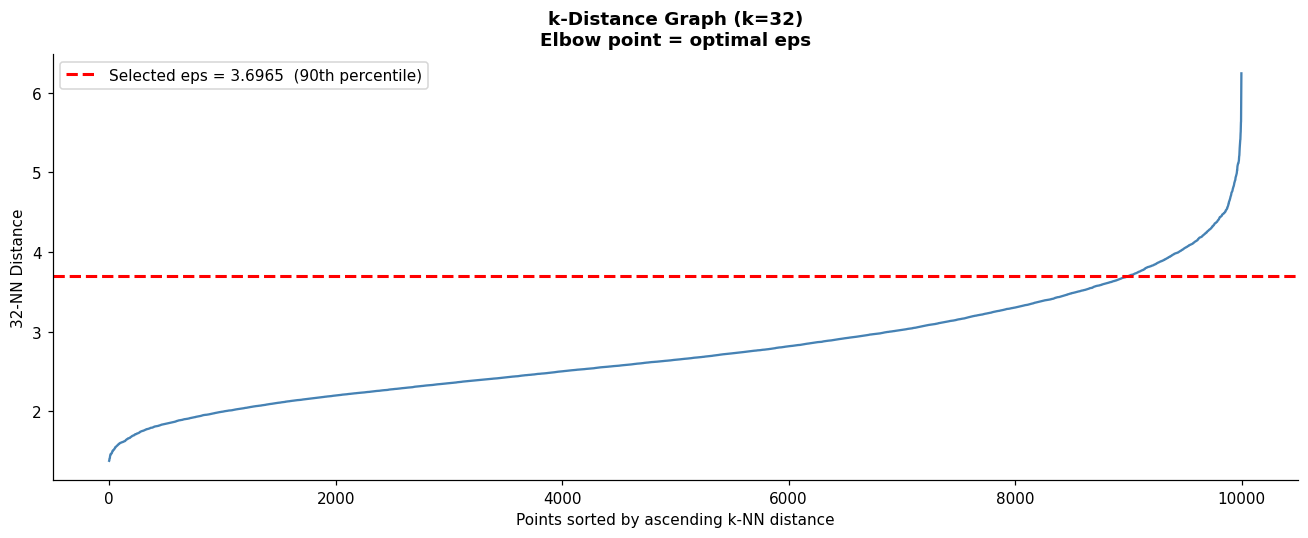


Selected eps = 3.6965
Running DBSCAN on 10,000 rows...

DBSCAN Results:
  eps            : 3.6965
  min_samples    : 32
  Clusters found : 1
  Noise points   : 164 (1.6%)


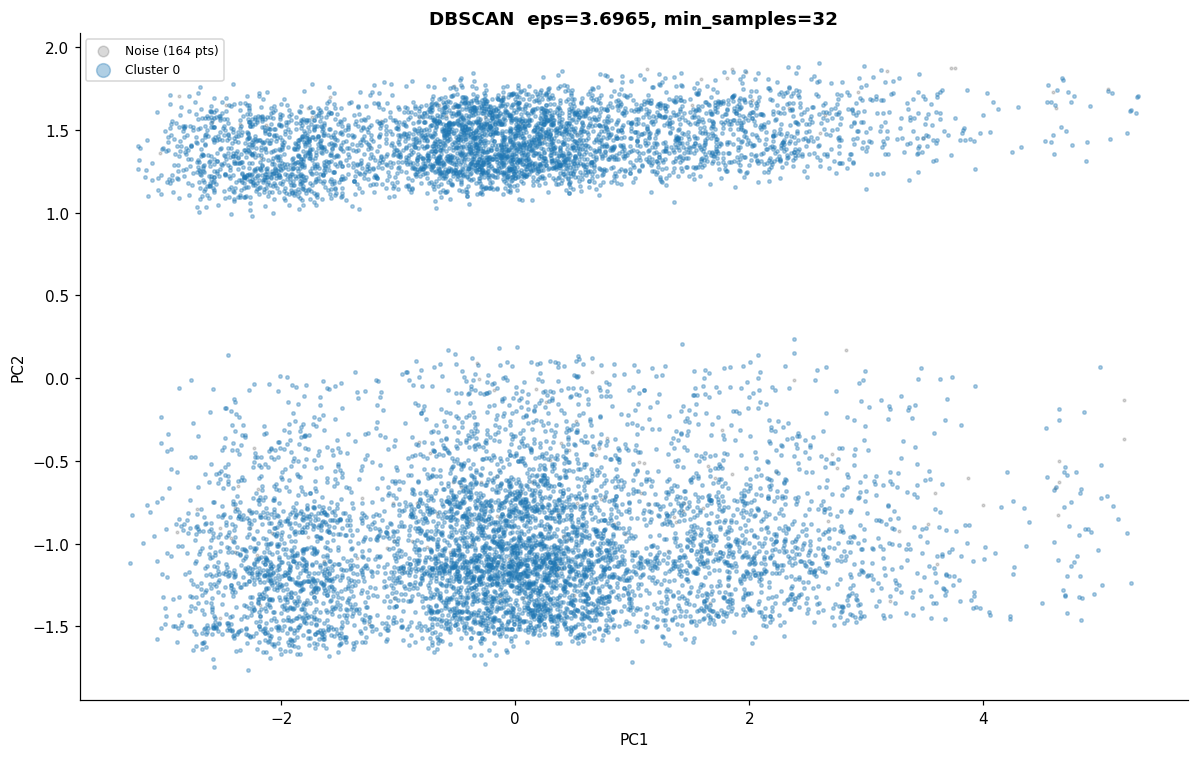


DBSCAN cluster distribution:
  NOISE          :      164 (1.6%)
  Cluster 0      :    9,836 (98.4%)


In [21]:
# ── DBSCAN: k-distance graph to find optimal eps ─────────────────────────────
DBSCAN_SAMPLE  = min(20_000, len(X_pca))
db_idx         = np.random.default_rng(RANDOM_STATE).choice(len(X_pca), DBSCAN_SAMPLE, replace=False)
X_db_sub       = X_pca[db_idx]
min_samples_db = max(5, 2 * X_pca.shape[1])

print(f'min_samples (2 x PCA dims = 2 x {X_pca.shape[1]}): {min_samples_db}')
print(f'Running {min_samples_db}-NN on {DBSCAN_SAMPLE:,} subsample...')

nbrs = NearestNeighbors(n_neighbors=min_samples_db, n_jobs=-1).fit(X_db_sub)
distances, _ = nbrs.kneighbors(X_db_sub)
k_distances  = np.sort(distances[:, -1])
eps_auto     = float(np.percentile(k_distances, 90))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_distances, color='steelblue', linewidth=1.5)
ax.axhline(eps_auto, color='red', linestyle='--', linewidth=2,
           label=f'Selected eps = {eps_auto:.4f}  (90th percentile)')
ax.set_title(f'k-Distance Graph (k={min_samples_db})\nElbow point = optimal eps',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Points sorted by ascending k-NN distance')
ax.set_ylabel(f'{min_samples_db}-NN Distance')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nSelected eps = {eps_auto:.4f}')
print(f'Running DBSCAN on {len(X_pca):,} rows...')

dbscan    = DBSCAN(eps=eps_auto, min_samples=min_samples_db, n_jobs=-1)
db_labels = dbscan.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = int(np.sum(db_labels == -1))

print(f'\nDBSCAN Results:')
print(f'  eps            : {eps_auto:.4f}')
print(f'  min_samples    : {min_samples_db}')
print(f'  Clusters found : {n_clusters_db}')
print(f'  Noise points   : {n_noise_db:,} ({n_noise_db/len(db_labels)*100:.1f}%)')

if n_clusters_db >= 2:
    mask_valid = db_labels != -1
    sil_db = silhouette_score(X_pca[mask_valid], db_labels[mask_valid],
                              sample_size=10_000, random_state=RANDOM_STATE)
    db_db  = davies_bouldin_score(X_pca[mask_valid], db_labels[mask_valid])
    ch_db  = calinski_harabasz_score(X_pca[mask_valid], db_labels[mask_valid])
    print(f'  Silhouette Score     : {sil_db:.4f}')
    print(f'  Davies-Bouldin Score : {db_db:.4f}')
    print(f'  Calinski-Harabasz    : {ch_db:.2f}')
else:
    sil_db = np.nan; db_db = np.nan; ch_db = np.nan
    print('  WARNING: < 2 clusters found — try reducing eps or min_samples')

# ── DBSCAN scatter ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for lbl in sorted(set(db_labels)):
    mask     = db_labels == lbl
    is_noise = lbl == -1
    color    = 'black' if is_noise else palette[lbl % 10]
    label    = f'Noise ({n_noise_db:,} pts)' if is_noise else f'Cluster {lbl}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=3 if is_noise else 5,
               alpha=0.15 if is_noise else 0.35,
               color=color, label=label, rasterized=True)
ax.set_title(f'DBSCAN  eps={eps_auto:.4f}, min_samples={min_samples_db}', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=8, markerscale=4)
plt.tight_layout()
plt.show()

print('\nDBSCAN cluster distribution:')
for lbl in sorted(set(db_labels)):
    cnt  = np.sum(db_labels == lbl)
    name = 'NOISE' if lbl == -1 else f'Cluster {lbl}'
    print(f'  {name:<15}: {cnt:>8,} ({cnt/len(db_labels)*100:.1f}%)')

## 4.3 Agglomerative Hierarchical Clustering

Builds a **bottom-up hierarchy** of merges:
1. Each point starts as its own cluster
2. Merge the two closest clusters
3. Repeat until one cluster remains
4. Cut tree at desired K

**Linkage criterion:**

| Linkage | Distance | Shape | Selected |
|---|---|---|---|
| **Ward** | Minimises total within-cluster variance | Compact | Yes |
| Complete | Max distance between members | Compact | No |
| Average | Mean distance | Variable | No |
| Single | Min distance | Elongated | No |

**Reading the dendrogram:** longest vertical lines before final merges = natural cut point.

Computing Ward linkage on 2,000-row subsample...


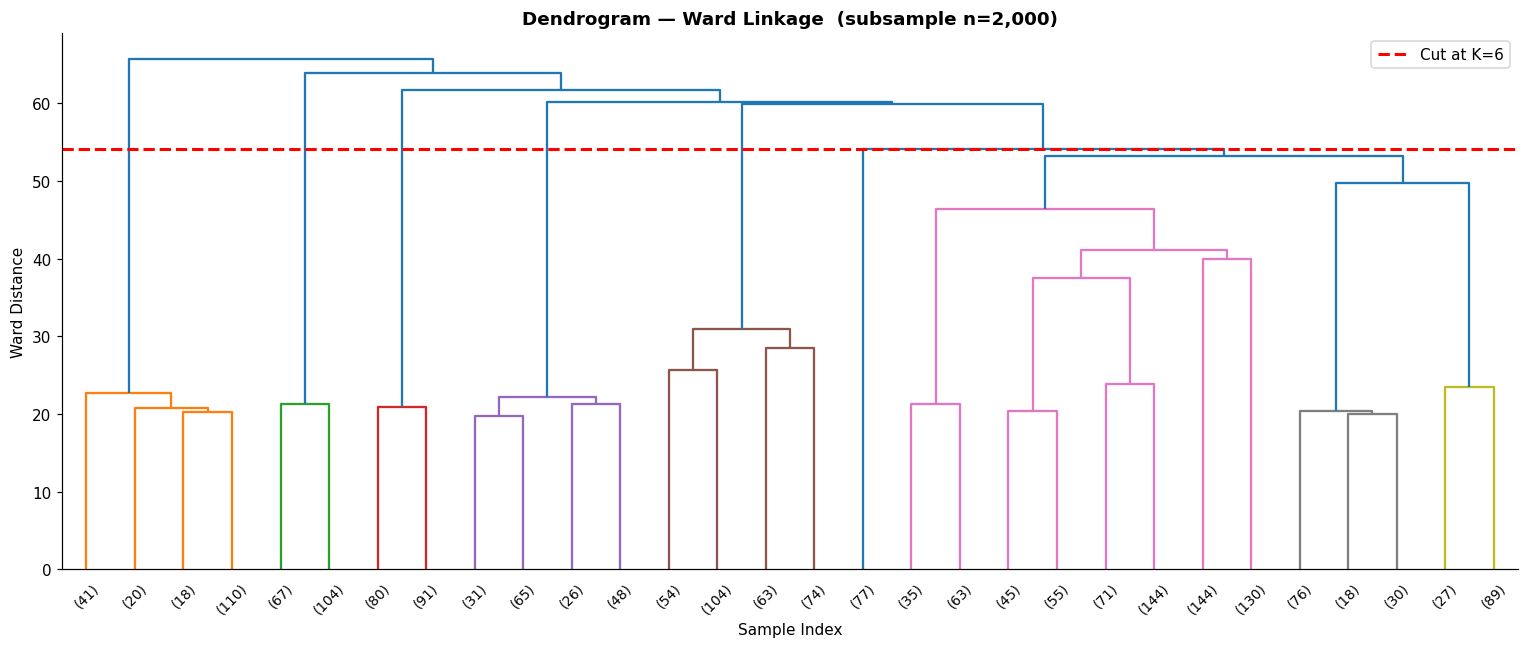


Fitting Agglomerative (n_clusters=6, linkage=ward)...

Agglomerative (K=6, Ward) Metrics:
  Silhouette Score     : 0.1532
  Davies-Bouldin Score : 2.1299
  Calinski-Harabasz    : 636.96


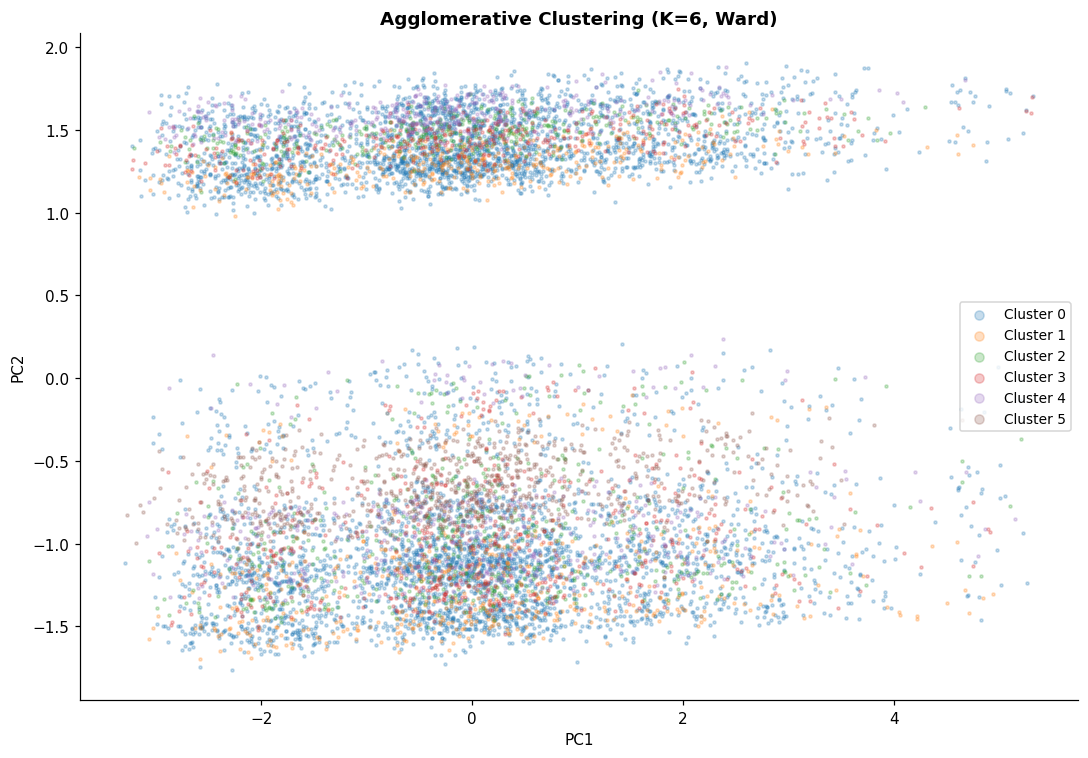


Agglomerative cluster sizes:
  Cluster 0:   5,548 (55.5%)
  Cluster 1:     943 (9.4%)
  Cluster 2:     987 (9.9%)
  Cluster 3:     919 (9.2%)
  Cluster 4:     839 (8.4%)
  Cluster 5:     764 (7.6%)


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Re-establish parameters from earlier analyses if kernel state was lost
RANDOM_STATE = 42        # From cell kAx0sbChQrZ3
N_PCA = 16               # From cell rl793BJ3SOnN output: 'Selected N_PCA = 16 components'
best_k = 6               # From cell 0oE9FF4YSbuM output: 'Best K by Silhouette Score: K = 6'
palette = plt.cm.tab10.colors # From cell DAt3PxBeSgB3

# Re-create X_pca within this cell, assuming X_scaled is available from upstream cells.
# If X_scaled is also undefined, please ensure cell ujfk9yflSGO2 (Normalization) has been run.
pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# ── Dendrogram on 2,000-row subsample ────────────────────────────────────────
DENDRO_SAMPLE = 2_000
dend_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_pca), DENDRO_SAMPLE, replace=False)
X_dend   = X_pca[dend_idx]

print(f'Computing Ward linkage on {DENDRO_SAMPLE:,}-row subsample...')
linkage_matrix = linkage(X_dend, method='ward', optimal_ordering=False)

fig, ax = plt.subplots(figsize=(14, 6))
dendro = dendrogram(
    linkage_matrix, ax=ax,
    truncate_mode='lastp', p=30,
    leaf_rotation=45, leaf_font_size=9,
    color_threshold=linkage_matrix[-best_k, 2] * 0.9
)
ax.axhline(linkage_matrix[-best_k, 2], color='red', linestyle='--',
           linewidth=2, label=f'Cut at K={best_k}')
ax.set_title(f'Dendrogram — Ward Linkage  (subsample n={DENDRO_SAMPLE:,})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.show()

# ── Agglomerative Clustering ──────────────────────────────────────────────────
AGG_K = best_k
print(f'\nFitting Agglomerative (n_clusters={AGG_K}, linkage=ward)...')
agg        = AgglomerativeClustering(n_clusters=AGG_K, linkage='ward')
agg_labels = agg.fit_predict(X_pca)

sil_agg = silhouette_score(X_pca, agg_labels, sample_size=10_000, random_state=RANDOM_STATE)
db_agg  = davies_bouldin_score(X_pca, agg_labels)
ch_agg  = calinski_harabasz_score(X_pca, agg_labels)

print(f'\nAgglomerative (K={AGG_K}, Ward) Metrics:')
print(f'  Silhouette Score     : {sil_agg:.4f}')
print(f'  Davies-Bouldin Score : {db_agg:.4f}')
print(f'  Calinski-Harabasz    : {ch_agg:.2f}')

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(AGG_K):
    mask = agg_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=4, alpha=0.25, color=palette[c % 10], label=f'Cluster {c}', rasterized=True)
ax.set_title(f'Agglomerative Clustering (K={AGG_K}, Ward)', fontsize=12, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9, markerscale=3)
plt.tight_layout()
plt.show()

print('\nAgglomerative cluster sizes:')
for c in range(AGG_K):
    cnt = np.sum(agg_labels == c)
    print(f'  Cluster {c}: {cnt:>7,} ({cnt/len(agg_labels)*100:.1f}%)')


---
# TASK 5 — Cluster Profiling & Business Interpretation

## 5.1 K-Means Cluster Profiles

K-Means cluster labels are re-attached to **original (pre-scaling) feature values** for interpretability.

This lets us say: **'Cluster 2 users spend on average 6.8 hours/day on social media'** rather than scaled numbers.

In [23]:
# ── Cluster Profile: mean of original features per cluster ───────────────────
profile_df = X_selected.copy()
profile_df['kmeans_cluster'] = km_labels

cluster_profile = profile_df.groupby('kmeans_cluster').mean().round(4).T
cluster_sizes_profile = profile_df['kmeans_cluster'].value_counts().sort_index()

print('=== K-Means Cluster Profiles (Mean per Feature) ===')
print(cluster_profile.to_string())

print('\n=== Cluster Sizes ===')
for c, cnt in cluster_sizes_profile.items():
    pct = cnt / len(profile_df) * 100
    bar = 'x' * int(pct / 2)
    print(f'  Cluster {c}: {cnt:>7,} users ({pct:5.1f}%)  {bar}')

=== K-Means Cluster Profiles (Mean per Feature) ===
kmeans_cluster                   0        1        2        3        4        5        6
age                        19.7482  19.9380  19.8903  20.0845  20.0360  19.9910  20.0523
daily_usage_hours           3.4274   3.5060   5.2835   3.4624   2.9964   3.3400   3.4884
num_platforms_used          2.9747   3.1111   2.9368   3.0288   3.0152   3.0017   3.0542
avg_session_minutes        25.7814  25.5359  17.6321  25.1671  26.7629  26.2933  25.3043
night_usage                 0.6154   0.5844   0.5968   0.5931   0.5833   0.5983   0.5897
screen_time_before_sleep   39.8273  39.6149  40.4196  39.8642  40.2067  38.7762  40.6405
session_intensity           8.9773   9.4681  21.2394   9.3228   7.0800   8.3479   9.5013
addiction_level_ord         0.8841   0.9316   1.6866   0.8762   0.6740   0.8322   0.8836
gender_Male                 0.4647   0.4722   0.4505   0.4904   0.4812   0.4859   0.4694
gender_Other                0.0348   0.0353   0.0374   0.0

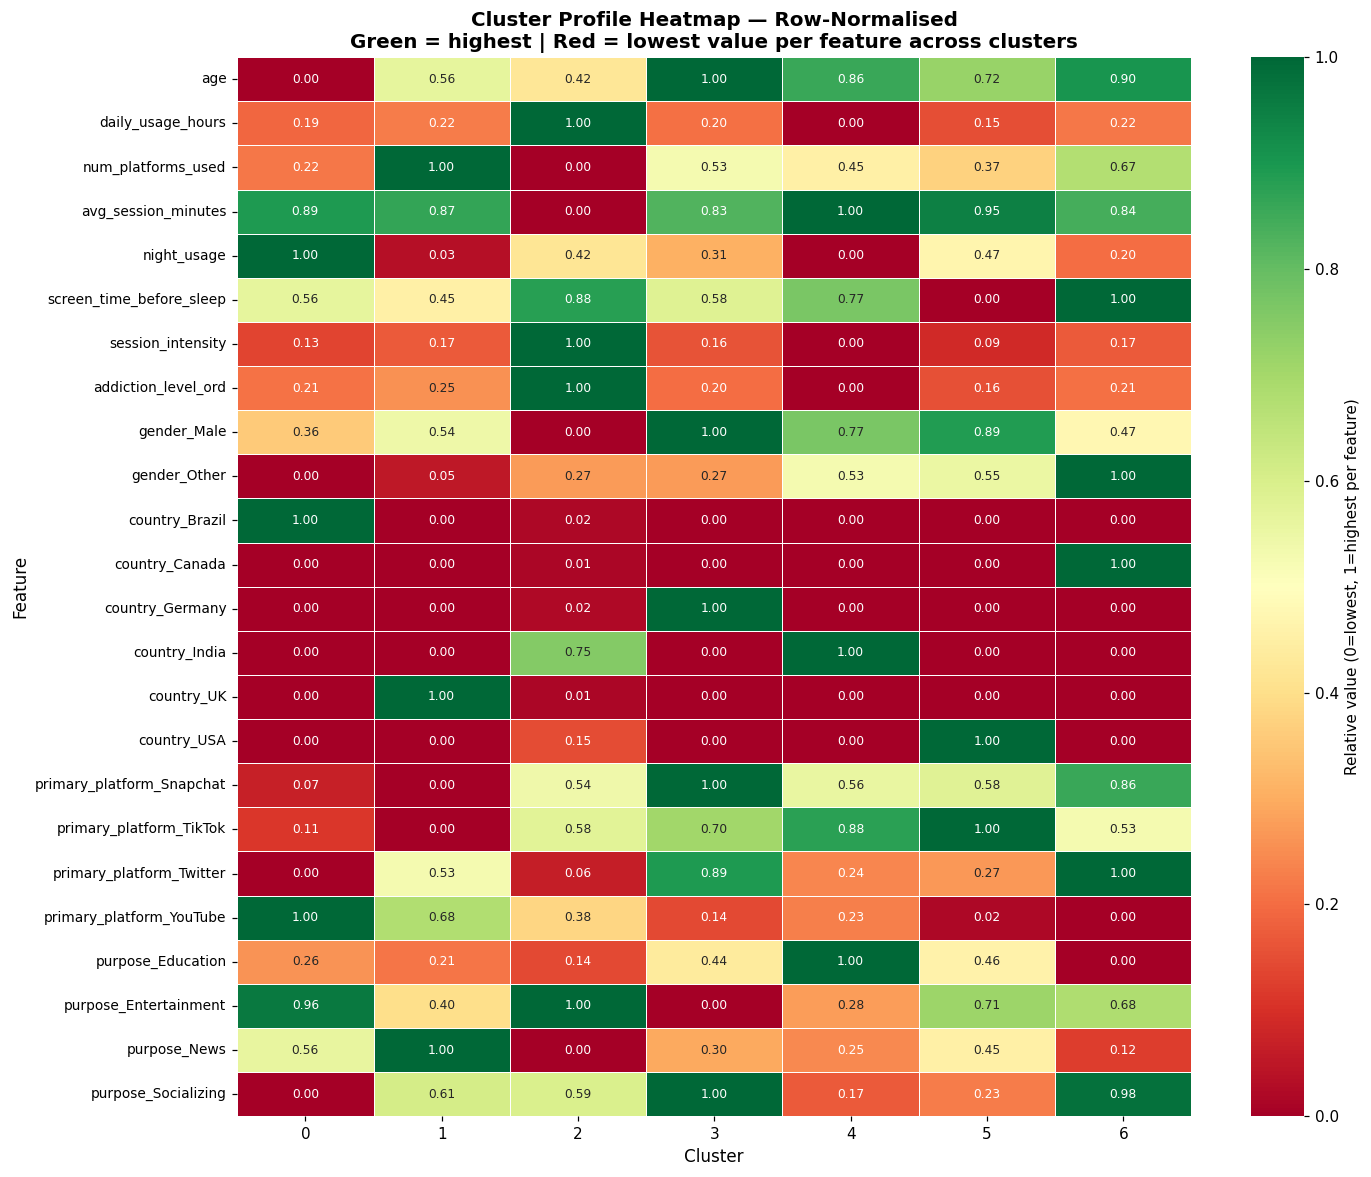

In [24]:
# ── Cluster Profile Heatmap (row-normalised 0-1) ─────────────────────────────
profile_norm = cluster_profile.copy().astype(float)
for feat in profile_norm.index:
    rmin = profile_norm.loc[feat].min()
    rmax = profile_norm.loc[feat].max()
    if rmax > rmin:
        profile_norm.loc[feat] = (profile_norm.loc[feat] - rmin) / (rmax - rmin)
    else:
        profile_norm.loc[feat] = 0.5

fig_h = max(10, len(profile_norm) * 0.45)
fig_w = max(8, best_k * 2.2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

sns.heatmap(
    profile_norm, annot=True, fmt='.2f',
    cmap='RdYlGn', ax=ax, linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Relative value (0=lowest, 1=highest per feature)'}
)
ax.set_title(
    'Cluster Profile Heatmap — Row-Normalised\n'
    'Green = highest | Red = lowest value per feature across clusters',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

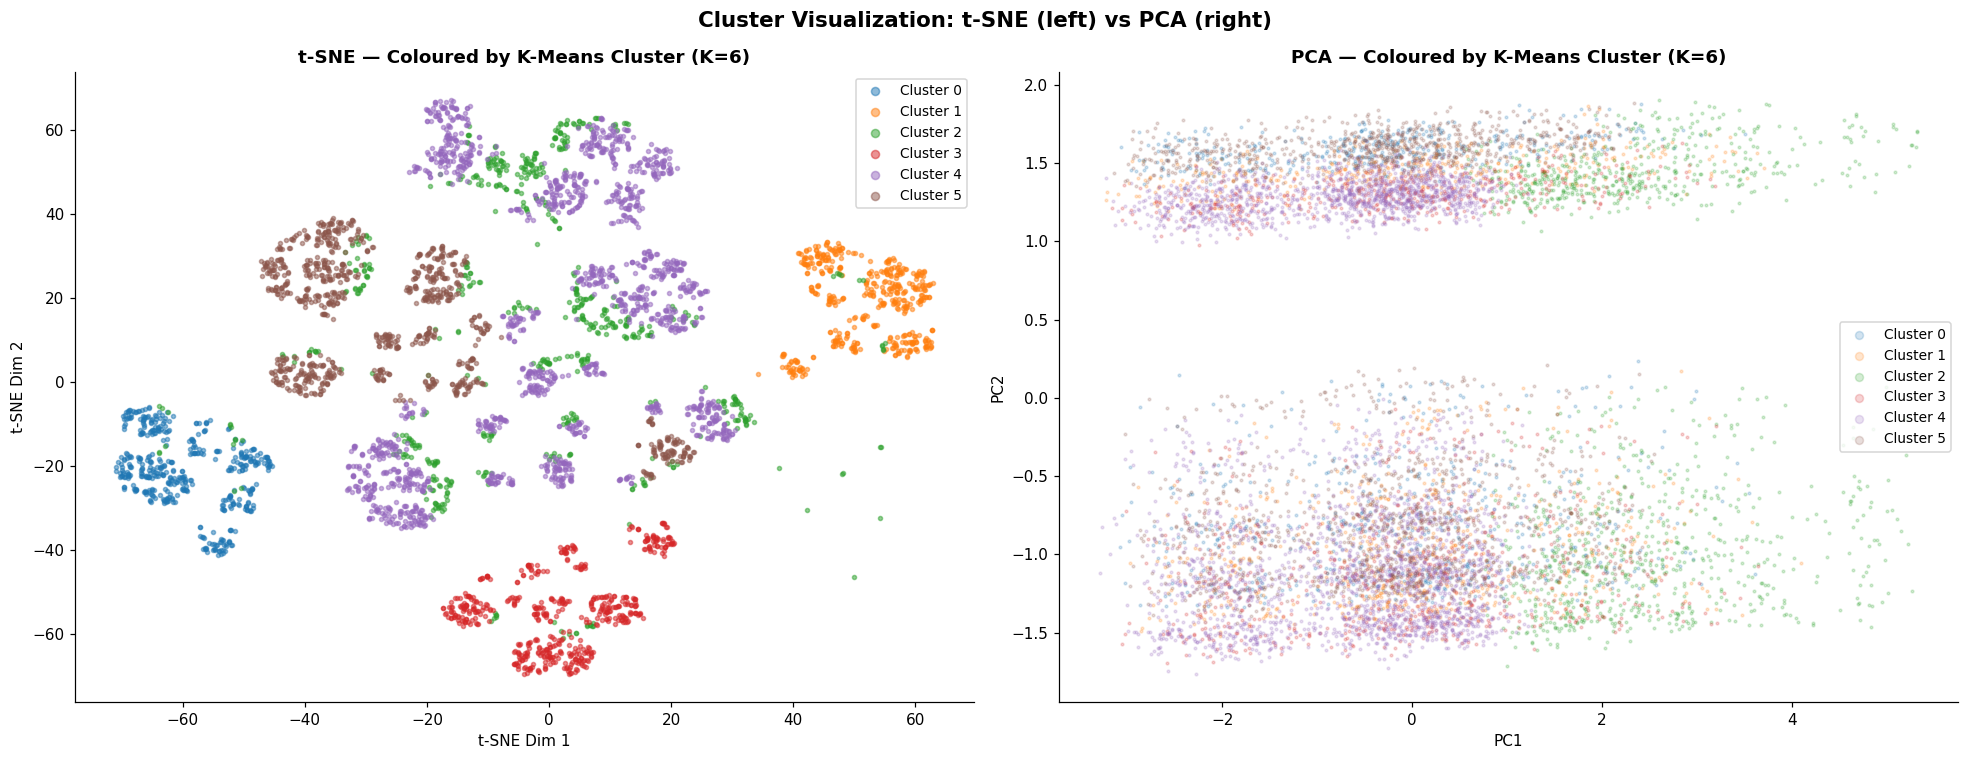


=== Cluster Label Interpretation (from heatmap above) ===
Assign descriptive names by reviewing the heatmap:
  Cluster 0 (949 users, 9.5%): [assign label from heatmap]
  Cluster 1 (936 users, 9.4%): [assign label from heatmap]
  Cluster 2 (1,203 users, 12.0%): [assign label from heatmap]
  Cluster 3 (1,042 users, 10.4%): [assign label from heatmap]
  Cluster 4 (3,086 users, 30.9%): [assign label from heatmap]
  Cluster 5 (1,770 users, 17.7%): [assign label from heatmap]

Example labels:
  Highest daily_usage_hours + highest addiction_level_ord -> "Heavy At-Risk Users"
  Lowest usage + lowest night_usage                      -> "Casual Healthy Users"
  High num_platforms_used                                -> "Multi-Platform Moderates"


In [26]:
# ── t-SNE + PCA coloured by K-Means cluster ──────────────────────────────────
tsne_km_labels = km_labels[tsne_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for c in range(best_k):
    mask = tsne_km_labels == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], s=7, alpha=0.5,
               color=palette[c % 10], label=f'Cluster {c}')
ax.set_title(f't-SNE — Coloured by K-Means Cluster (K={best_k})', fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE Dim 1'); ax.set_ylabel('t-SNE Dim 2')
ax.legend(fontsize=9, markerscale=2)

ax2 = axes[1]
for c in range(best_k):
    mask = km_labels == c
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1], s=3, alpha=0.2,
                color=palette[c % 10], label=f'Cluster {c}', rasterized=True)
ax2.set_title(f'PCA — Coloured by K-Means Cluster (K={best_k})', fontsize=12, fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')
ax2.legend(fontsize=9, markerscale=3)

plt.suptitle('Cluster Visualization: t-SNE (left) vs PCA (right)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== Cluster Label Interpretation (from heatmap above) ===')
print('Assign descriptive names by reviewing the heatmap:')
for c in range(best_k):
    cnt = np.sum(km_labels == c)
    pct = cnt / len(km_labels) * 100
    print(f'  Cluster {c} ({cnt:,} users, {pct:.1f}%): [assign label from heatmap]')
print('\nExample labels:')
print('  Highest daily_usage_hours + highest addiction_level_ord -> "Heavy At-Risk Users"')
print('  Lowest usage + lowest night_usage                      -> "Casual Healthy Users"')
print('  High num_platforms_used                                -> "Multi-Platform Moderates"')


---
# TASK 6 — Model Comparison & Evaluation

## 6.1 Metric Explanations

**Silhouette Score:** `s(i) = (b(i) - a(i)) / max(a(i), b(i))`  
where `a(i)` = mean intra-cluster distance, `b(i)` = mean distance to nearest other cluster.  
Range: -1 to +1. Higher = better.

**Davies-Bouldin:** Mean of max cluster-similarity ratios. Range >= 0. Lower = better.

**Calinski-Harabasz:** Between-cluster variance / Within-cluster variance. Higher = better.

## 6.2 Model Strengths & Weaknesses

| Model | Strengths | Weaknesses |
|---|---|---|
| **K-Means** | Fast, scalable, interpretable | Assumes spherical clusters; K must be set |
| **DBSCAN** | No K needed; finds noise; any shape | Hard to tune; poor in high dims |
| **Agglomerative** | No K upfront; dendrogram | O(n2) memory; slow on large data |


      UNSUPERVISED CLUSTERING — MODEL COMPARISON
                            Clusters  Noise  Silhouette  Davies-Bouldin  Calinski-Harabasz
Model                                                                                     
K-Means (K=6)                      6      0      0.1478          2.0852             754.44
DBSCAN (eps=3.696, min=32)         1    164         NaN             NaN                NaN
Agglomerative (K=6, Ward)          6      0      0.1532          2.1299             636.96

Metric guide:
  Silhouette     : Higher is better (range -1 to +1)
  Davies-Bouldin : Lower is better  (range >= 0)
  Calinski-Harab.: Higher is better (range >= 0)


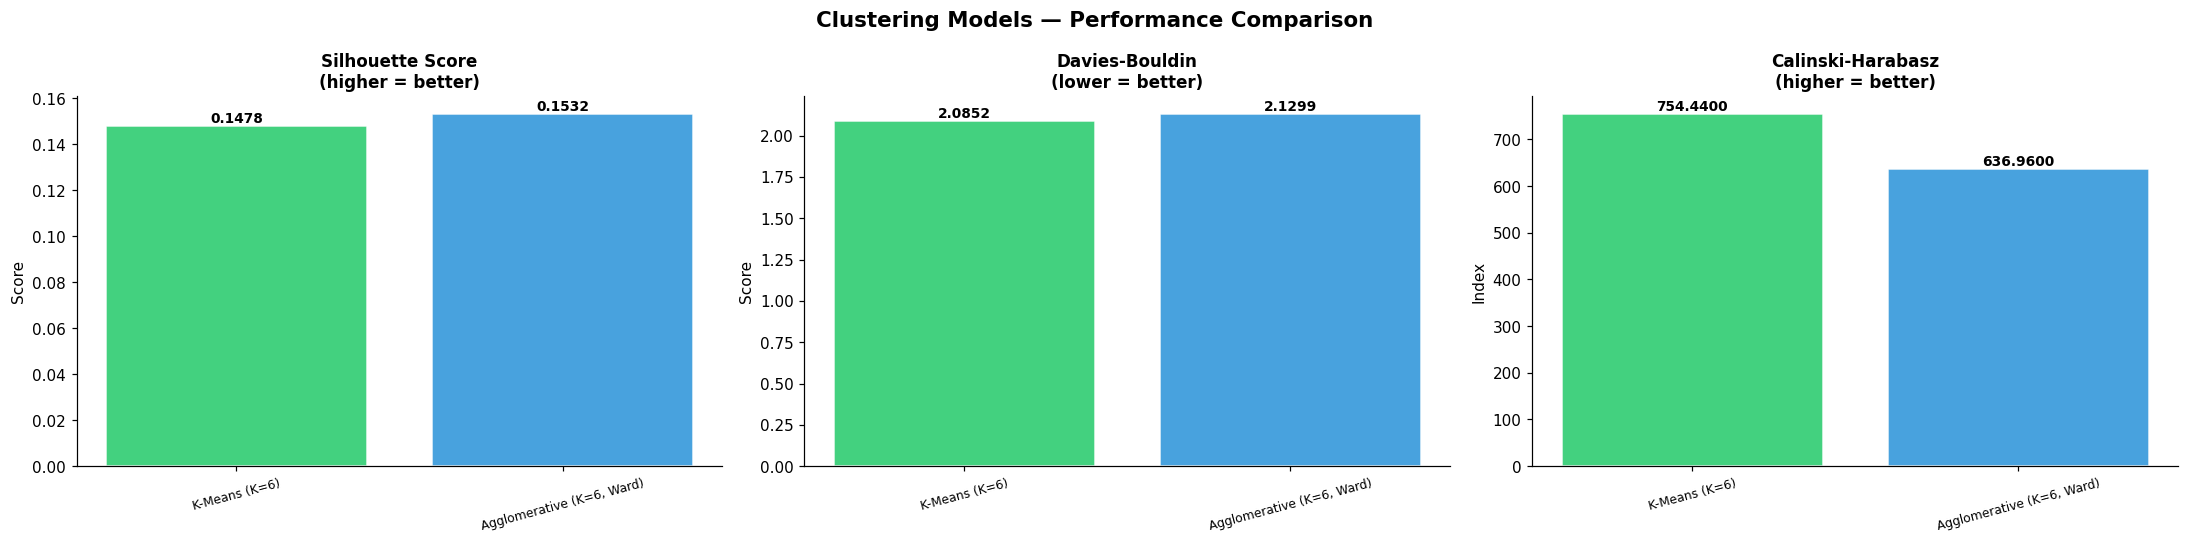


Best Model by Silhouette Score: Agglomerative (K=6, Ward)
  Silhouette Score : 0.1532


In [27]:
# ── Build comparison table ───────────────────────────────────────────────────
sil_db_val = round(sil_db, 4) if not np.isnan(sil_db) else float('nan')
db_db_val  = round(db_db,  4) if not np.isnan(db_db)  else float('nan')
ch_db_val  = round(ch_db,  2) if not np.isnan(ch_db)  else float('nan')

comparison_data = [
    {'Model': f'K-Means (K={best_k})',
     'Clusters': best_k, 'Noise': 0,
     'Silhouette': round(sil_final, 4),
     'Davies-Bouldin': round(db_final, 4),
     'Calinski-Harabasz': round(ch_final, 2)},
    {'Model': f'DBSCAN (eps={eps_auto:.3f}, min={min_samples_db})',
     'Clusters': n_clusters_db, 'Noise': n_noise_db,
     'Silhouette': sil_db_val,
     'Davies-Bouldin': db_db_val,
     'Calinski-Harabasz': ch_db_val},
    {'Model': f'Agglomerative (K={AGG_K}, Ward)',
     'Clusters': AGG_K, 'Noise': 0,
     'Silhouette': round(sil_agg, 4),
     'Davies-Bouldin': round(db_agg, 4),
     'Calinski-Harabasz': round(ch_agg, 2)},
]

comp_df = pd.DataFrame(comparison_data).set_index('Model')
print('\n' + '='*75)
print('      UNSUPERVISED CLUSTERING — MODEL COMPARISON')
print('='*75)
print(comp_df.to_string())
print('='*75)
print('\nMetric guide:')
print('  Silhouette     : Higher is better (range -1 to +1)')
print('  Davies-Bouldin : Lower is better  (range >= 0)')
print('  Calinski-Harab.: Higher is better (range >= 0)')

# ── Visual comparison charts ──────────────────────────────────────────────────
valid_rows  = [r for r in comparison_data if not np.isnan(r['Silhouette'])]
model_names = [r['Model'] for r in valid_rows]
sil_vals_v  = [r['Silhouette'] for r in valid_rows]
db_vals_v   = [r['Davies-Bouldin'] for r in valid_rows]
ch_vals_v   = [r['Calinski-Harabasz'] for r in valid_rows if not np.isnan(r['Calinski-Harabasz'])]
ch_names_v  = [r['Model'] for r in valid_rows if not np.isnan(r['Calinski-Harabasz'])]

bar_colors_v = ['#2ecc71', '#3498db', '#e67e22']
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, names, vals, title, ylabel in [
    (axes[0], model_names, sil_vals_v, 'Silhouette Score\n(higher = better)', 'Score'),
    (axes[1], model_names, db_vals_v,  'Davies-Bouldin\n(lower = better)',    'Score'),
    (axes[2], ch_names_v,  ch_vals_v,  'Calinski-Harabasz\n(higher = better)','Index'),
]:
    bars = ax.bar(names, vals, color=bar_colors_v[:len(names)], edgecolor='white', alpha=0.9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals) * 0.01,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Clustering Models — Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_idx        = np.argmax(sil_vals_v)
best_model_name = model_names[best_idx]
best_sil        = sil_vals_v[best_idx]
print(f'\nBest Model by Silhouette Score: {best_model_name}')
print(f'  Silhouette Score : {best_sil:.4f}')

---
# TASK 7 — Business Recommendations

## 7.1 User Segments Discovered

| Archetype | Cluster Signal | Profile |
|---|---|---|
| **Casual Healthy Users** | Low usage, low addiction, low night_usage | Occasional use; healthy sleep; low risk |
| **Heavy At-Risk Users** | High usage, high addiction, high screen_time_before_sleep | Excessive use; late-night scrolling; highest risk |
| **Multi-Platform Moderates** | High num_platforms_used, moderate usage | Spread across many apps; diverse diet |
| **Young Occasional Users** | Low age, moderate session_intensity | Younger demographic; periodic spikes |

> Assign cluster numbers from your heatmap output to the archetypes above.

---

## 7.2 Recommendation 1 — Wellbeing Interventions for At-Risk Segment

**Target:** Highest `daily_usage_hours` + `addiction_level_ord` cluster  
**Action:** Automated usage nudges at daily threshold. 'Digital Sunset' mode after 9 PM. Weekly detox challenges.  
**KPI:** Reduction in >6hr/day usage; improvement in self-reported wellbeing scores.

---

## 7.3 Recommendation 2 — Segment-Matched Product Features

| Segment | Feature |
|---|---|
| Casual Healthy | Discovery features, new platform recommendations |
| Heavy At-Risk | Usage dashboards; session reminders every 90 min |
| Multi-Platform | Cross-platform analytics; content aggregation |
| Young Users | Parental controls; age-appropriate content; study mode |

---

## 7.4 Recommendation 3 — Real-Time Segmentation at Signup

Deploy K-Means as a microservice. Collect 3-5 onboarding questions → predict cluster → personalise first session.

```python
import joblib
joblib.dump(km_final, 'kmeans_model.pkl')
joblib.dump(scaler,   'scaler.pkl')
joblib.dump(pca,      'pca.pkl')

# At inference:
cluster = km_final.predict(pca.transform(scaler.transform(new_user_features)))